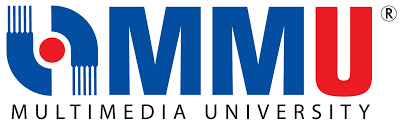

# CDS6344 Social Media Computing  
## Assignment Part 3: Project Code Repository  

### Project Title  
**Aspect-Based Sentiment Analysis of Social Networking App Reviews Using Machine Learning and Transformer Models**

### Group Information  

| Group Number | Student Name | Student ID |
|---|---|---|
| 9 | Venggadanaathan | 1231303562 |
| 9 | Tharraniah Tamilwanan | 1211111799 |

### Dataset  
**AWARE_Social_Networking.csv**

### Notebook 2 Purpose  
This notebook performs the second part of the project pipeline:

1. Loading the cleaned aspect-level dataset from Notebook 1  
2. Aspect term analysis  
3. Custom positive and negative opinion word extraction  
4. Lexicon-based sentiment comparison using VADER  
5. Explicit and implicit opinion analysis  
6. ABSA insight generation  
7. Exporting opinion mining and ABSA result files for the final report, presentation, and GitHub repository  

### Main Focus of Notebook 2  
Notebook 2 focuses on **Opinion Mining** and **Aspect-Based Sentiment Analysis insights**.  

It separates:

- **Aspect terms**: what users are discussing  
- **Opinion words**: how users feel about those aspects  
- **Aspect sentiment**: whether each aspect is positive or negative  

# 1. Notebook 2 Alignment with Assignment Requirements

This notebook supports the assignment requirements for:

| Assignment Requirement | Notebook 2 Support |
|---|---|
| Opinion Mining | Extracts opinion words and opinion expressions |
| Aspect-Based Sentiment Analysis | Analyses aspect categories, aspect terms, and aspect sentiments |
| Visualization | Produces report-ready charts and heatmaps |
| Discussion | Provides evidence for key findings and limitations |
| Appendix | Exports CSV result tables and visualization files |

The cleaned aspect-level dataset from Notebook 1 is used in this notebook.  
Each row represents an opinion-related aspect entry from a social networking app review.

Important dataset fields:

| Column | Purpose |
|---|---|
| `sentence` | Sentence-level text for opinion analysis |
| `category` | Aspect category |
| `term` | Aspect term mentioned in the review sentence |
| `sentiment` | Dataset-provided aspect sentiment label |
| `rating` | Original 1–5 user rating |
| `rating_sentiment` | Rating-based sentiment created in Notebook 1 |
| `app` | Social networking app name |
| `aspect_model_input` | Combined sentence + category + term input for modelling |

# 2. Why Custom Opinion Mining Is Needed

During earlier testing, general word frequency and word clouds produced many common aspect-related nouns such as:

```text
account, server, setting, photo, notification, sound



# **Import Libraries**

In [ ]:
# This cell imports libraries required for:
# - loading the cleaned aspect-level dataset
# - aspect term analysis
# - custom opinion word extraction
# - VADER lexicon-based sentiment comparison
# - visualization and output export
#
# Assignment usage:
# - Supports Opinion Mining
# - Supports ABSA analysis
# - Supports Result & Visualization
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
import zipfile
import shutil
import warnings

from collections import Counter

import nltk
nltk.download("vader_lexicon", quiet=True)

from nltk.sentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# **Set Chart Style**

In [ ]:
# This cell sets a consistent professional style for all
# Notebook 2 visualizations.
#
# The same color theme is used across notebooks so the report
# and PowerPoint look consistent.
# ============================================================

sns.set_theme(style="whitegrid")

SENTIMENT_COLORS = {
    "Positive": "#2EAD65",
    "Neutral": "#F2B84B",
    "Negative": "#D94F4F",
    "positive": "#2EAD65",
    "negative": "#D94F4F",
    "neutral": "#F2B84B"
}

MAIN_BLUE = "#2563EB"
MAIN_PURPLE = "#7C3AED"
MAIN_ORANGE = "#F97316"
MAIN_TEAL = "#0D9488"
MAIN_RED = "#DC2626"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"

print("Chart style configured successfully.")

Chart style configured successfully.


# **Create Clean Output Folders**

In [ ]:
# This cell creates clean output folders for Notebook 2.
#
# Important:
# Existing Notebook 2 results, visualizations, and exports folders
# are cleared first to prevent old files from mixing with final outputs.
# ============================================================

output_folders = ["results_notebook2", "visualizations_notebook2", "exports_notebook2"]

for folder in output_folders:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)

print("Clean Notebook 2 folders created:")
print("- results_notebook2/")
print("- visualizations_notebook2/")
print("- exports_notebook2/")

Clean Notebook 2 folders created:
- results_notebook2/
- visualizations_notebook2/
- exports_notebook2/


# **Helper Function for Bar Labels**

In [ ]:
# This helper function adds value labels to bar charts.
# It improves readability for report and presentation visuals.
# ============================================================

def add_bar_labels(ax, fmt="{:.0f}", padding=3):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding, fontsize=9)

# 3. Load Cleaned Aspect-Level Dataset

Upload the cleaned aspect-level dataset created in Notebook 1:

```text
aspect_level_social_reviews.csv

This dataset is the main input for Notebook 2.

It contains:

- sentence-level review text
- aspect categories
- aspect terms
- aspect sentiment labels
- app names
- ratings
- rating-based sentiment
- cleaned sentence text
- model input text

# **Upload Dataset**

In [ ]:
# This cell uploads the cleaned aspect-level dataset from Notebook 1.
#
# File required:
# aspect_level_social_reviews.csv
#
# This file is used for all opinion mining and ABSA insight analysis
# in Notebook 2.
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving aspect_level_social_reviews.csv to aspect_level_social_reviews.csv


## **Load Dataset**

In [ ]:
# This cell loads the cleaned aspect-level dataset into a DataFrame.
#
# DataFrame name:
# aspect_df
# ============================================================

file_name = "aspect_level_social_reviews.csv"

aspect_df = pd.read_csv(file_name)

print("Aspect-level dataset loaded successfully.")
print("Dataset shape:", aspect_df.shape)

aspect_df.head()

Aspect-level dataset loaded successfully.
Dataset shape: (3097, 20)


,domain,app,review_id,sentence_id,title,review,sentence,rating,rating_sentiment,is_opinion,category,term,from,to,sentiment,basic_clean_sentence,ml_clean_sentence,sentence_word_count,aspect_model_input,aspect_model_input_ml
0,social networking,whatsapp-messenger,aa65ef9e-27c0-496e-be43-089c1b186ff9,00437139-ab26-4f42-8050-8b464b0a90cd,Need video call through WhatsApp Web,I like WhatsApp to talk to friends that aren’t...,I just drained about 15-20 percent of my phone...,4,Positive,True,efficiency,video call,67.0,77.0,negative,i just drained about percent of my phone batte...,drained percent phone battery video call bet l...,24,i just drained about percent of my phone batte...,drained percent phone battery video call bet l...
1,social networking,discord,fb8b4293-2956-446e-9181-02ed3ceff8ac,007ecad5-2bd1-47de-b94c-4c367b7e2c59,Sharing Screens,"As a mobile user, it is unfortunate that we ca...","On an iPad Pro, I would honestly expect somewa...",4,Positive,True,effectiveness,share,52.0,57.0,negative,on an ipad pro i would honestly expect someway...,ipad pro would honestly expect someway share s...,18,on an ipad pro i would honestly expect someway...,ipad pro would honestly expect someway share s...
2,social networking,teamspeak-3,b9c54729-6dea-44da-877e-f1891cf977c6,0097e9d8-fe91-45d1-b66f-3e6cac36459e,Great!!,Does everything the desktop app does! Slight b...,Would be awesome if you could press the volume...,5,Positive,True,usability,volume,41.0,47.0,negative,would be awesome if you could press the volume...,would awesome could press volume button activa...,25,would be awesome if you could press the volume...,would awesome could press volume button activa...
3,social networking,free-tone-calling-texting,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,00a23065-9b78-483b-8bf3-21f1fe59bad8,"Deleted my credits and history, changed my number",I logged in today and my credits and history w...,I've always had trouble with the alerts not wo...,1,Negative,True,reliability,phone call,66.0,76.0,negative,i ve always had trouble with the alerts not wo...,always trouble alert not working get phone cal...,18,i ve always had trouble with the alerts not wo...,always trouble alert not working get phone cal...
4,social networking,discord,86ed17e1-571f-47ba-b405-d2b7991a3a42,0172311b-9191-45f5-a119-8bab09e21358,Wow!,"I’ve been using Skype for years as a gamer, an...",But the mobile recent update just killed it.,5,Positive,True,general,recent update,16.0,29.0,negative,but the mobile recent update just killed it,mobile recent update killed,8,but the mobile recent update just killed it [S...,mobile recent update killed sep general sep re...


# **Display Column Names**

In [ ]:
# This cell shows all columns in the cleaned aspect-level dataset.
#
# We verify that important columns such as sentence, category,
# term, sentiment, app, rating, and aspect_model_input exist.
# ============================================================

print("Columns in the aspect-level dataset:\n")

for i, col in enumerate(aspect_df.columns, start=1):
    print(f"{i}. {col}")

Columns in the aspect-level dataset:

1. domain
2. app
3. review_id
4. sentence_id
5. title
6. review
7. sentence
8. rating
9. rating_sentiment
10. is_opinion
11. category
12. term
13. from
14. to
15. sentiment
16. basic_clean_sentence
17. ml_clean_sentence
18. sentence_word_count
19. aspect_model_input
20. aspect_model_input_ml


# **Validate Required Columns**

In [ ]:
# This cell checks whether all required columns are available.
#
# If any column is missing, we must stop and fix the input file
# before continuing.
# ============================================================

required_columns = [
    "domain",
    "app",
    "review_id",
    "sentence_id",
    "title",
    "review",
    "sentence",
    "rating",
    "rating_sentiment",
    "is_opinion",
    "category",
    "term",
    "sentiment",
    "basic_clean_sentence",
    "ml_clean_sentence",
    "sentence_word_count",
    "aspect_model_input",
    "aspect_model_input_ml"
]

missing_columns = [col for col in required_columns if col not in aspect_df.columns]

if len(missing_columns) == 0:
    print("All required columns are available.")
else:
    print("Missing required columns:")
    print(missing_columns)

All required columns are available.


# **Dataset Information**

In [ ]:
# This cell shows data types and non-null counts.
#
# Assignment usage:
# - Confirms data quality before opinion mining
# - Supports the Methodology section if needed
# ============================================================

aspect_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3097 entries, 0 to 3096
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   domain                 3097 non-null   object 
 1   app                    3097 non-null   object 
 2   review_id              3097 non-null   object 
 3   sentence_id            3097 non-null   object 
 4   title                  3097 non-null   object 
 5   review                 3097 non-null   object 
 6   sentence               3097 non-null   object 
 7   rating                 3097 non-null   int64  
 8   rating_sentiment       3097 non-null   object 
 9   is_opinion             3097 non-null   bool   
 10  category               3097 non-null   object 
 11  term                   3097 non-null   object 
 12  from                   3079 non-null   float64
 13  to                     3079 non-null   float64
 14  sentiment              3097 non-null   object 
 15  basi

# **Missing Values Check**

In [ ]:
# This cell checks missing values in the cleaned aspect-level dataset.
#
# Expected:
# - term should already be filled
# - from/to may have missing values, but they are not essential
#   for Notebook 2 analysis.
# ============================================================

missing_values = aspect_df.isnull().sum().sort_values(ascending=False)

missing_values_df = missing_values.reset_index()
missing_values_df.columns = ["Column", "Missing Values"]

missing_values_df["Missing Percentage"] = (
    missing_values_df["Missing Values"] / len(aspect_df) * 100
).round(2)

missing_values_df

,Column,Missing Values,Missing Percentage
0,from,18,0.58
1,to,18,0.58
2,domain,0,0.00
3,app,0,0.00
4,sentence_id,0,0.00
5,review_id,0,0.00
6,title,0,0.00
7,review,0,0.00
8,rating_sentiment,0,0.00
9,is_opinion,0,0.00


# **Basic Dataset Summary**

In [ ]:
# This cell summarizes the main dataset properties.
#
# Assignment usage:
# - Useful for Notebook 2 summary
# - Confirms dataset size before analysis
# ============================================================

dataset_summary = {
    "Total aspect rows": aspect_df.shape[0],
    "Total columns": aspect_df.shape[1],
    "Unique reviews": aspect_df["review_id"].nunique(),
    "Unique sentences": aspect_df["sentence_id"].nunique(),
    "Unique apps": aspect_df["app"].nunique(),
    "Unique aspect categories": aspect_df["category"].nunique(),
    "Unique aspect terms": aspect_df["term"].nunique()
}

dataset_summary_df = pd.DataFrame(
    dataset_summary.items(),
    columns=["Metric", "Value"]
)

dataset_summary_df

,Metric,Value
0,Total aspect rows,3097
1,Total columns,20
2,Unique reviews,1615
3,Unique sentences,2965
4,Unique apps,6
5,Unique aspect categories,9
6,Unique aspect terms,85


# **Aspect Sentiment Distribution**

In [ ]:
# This cell checks the positive/negative aspect sentiment distribution.
#
# Assignment usage:
# - Confirms the ABSA sentiment label distribution
# - Important before opinion mining and model training
# ============================================================

aspect_sentiment_summary = (
    aspect_df["sentiment"]
    .value_counts()
    .reindex(["positive", "negative"])
    .reset_index()
)

aspect_sentiment_summary.columns = ["Aspect Sentiment", "Count"]

aspect_sentiment_summary["Percentage"] = (
    aspect_sentiment_summary["Count"] /
    aspect_sentiment_summary["Count"].sum() * 100
).round(2)

aspect_sentiment_summary.to_csv(
    "results_notebook2/aspect_sentiment_distribution.csv",
    index=False
)

aspect_sentiment_summary

,Aspect Sentiment,Count,Percentage
0,positive,1382,44.62
1,negative,1715,55.38


# **Aspect Category Distribution**

In [ ]:
# This cell checks how many rows belong to each aspect category.
#
# Assignment usage:
# - Confirms which app aspects are most discussed
# - Supports ABSA insight analysis
# ============================================================

aspect_category_summary = (
    aspect_df["category"]
    .value_counts()
    .reset_index()
)

aspect_category_summary.columns = ["Aspect Category", "Count"]

aspect_category_summary["Percentage"] = (
    aspect_category_summary["Count"] /
    aspect_category_summary["Count"].sum() * 100
).round(2)

aspect_category_summary.to_csv(
    "results_notebook2/aspect_category_distribution.csv",
    index=False
)

aspect_category_summary

,Aspect Category,Count,Percentage
0,usability,842,27.19
1,general,756,24.41
2,effectiveness,379,12.24
3,efficiency,337,10.88
4,security,284,9.17
5,cost,194,6.26
6,reliability,178,5.75
7,enjoyability,94,3.04
8,safety,33,1.07


# **App Distribution**

In [ ]:
# This cell checks how many aspect rows are available for each app.
#
# Assignment usage:
# - Supports app-level ABSA insights
# - Helps identify app-specific sentiment patterns
# ============================================================

app_distribution = (
    aspect_df["app"]
    .value_counts()
    .reset_index()
)

app_distribution.columns = ["App", "Aspect Row Count"]

app_distribution["Percentage"] = (
    app_distribution["Aspect Row Count"] /
    app_distribution["Aspect Row Count"].sum() * 100
).round(2)

app_distribution.to_csv(
    "results_notebook2/app_aspect_row_distribution.csv",
    index=False
)

app_distribution

,App,Aspect Row Count,Percentage
0,whatsapp-messenger,651,21.02
1,free-tone-calling-texting,647,20.89
2,discord,645,20.83
3,facebook,586,18.92
4,teamspeak-3,380,12.27
5,threema-the-secure-messenger,188,6.07


# **Term Frequency Preview**

In [ ]:
# This cell previews the most common aspect terms.
#
# Important:
# These are aspect terms, not necessarily opinion words.
# Opinion words will be extracted separately using a custom lexicon.
# ============================================================

term_frequency_preview = (
    aspect_df["term"]
    .astype(str)
    .str.lower()
    .str.strip()
    .value_counts()
    .head(25)
    .reset_index()
)

term_frequency_preview.columns = ["Aspect Term", "Frequency"]

term_frequency_preview.to_csv(
    "results_notebook2/aspect_term_frequency_preview.csv",
    index=False
)

term_frequency_preview

,Aspect Term,Frequency
0,notification,187
1,version,178
2,chat,153
3,account,147
4,group,145
5,photo,136
6,sound,111
7,money,111
8,setting,108
9,server,105


# 4. Aspect Term Analysis

This phase analyses the aspect terms mentioned in social networking app reviews.

The goal is to identify:

1. The most frequent positive aspect terms  
2. The most frequent negative aspect terms  
3. Aspect terms that receive both positive and negative sentiment  
4. High-risk aspect terms with the highest negative sentiment percentage  

This is more accurate than general word frequency because aspect terms represent the specific features or topics users discuss, such as:

- notification  
- account  
- server  
- privacy  
- group chat  
- phone call  
- recent update  

These outputs support the **Opinion Mining**, **Aspect-Based Sentiment Analysis**, **Result & Visualization**, and **Discussion** sections of the report.

# **Clean and Normalize Aspect Terms**

In [ ]:
# This cell creates a cleaned version of the aspect term column.
#
# Why this is needed:
# - Aspect terms may contain inconsistent capitalization or spacing.
# - Normalizing terms makes frequency analysis more accurate.
#
# Assignment usage:
# - Supports Opinion Mining
# - Supports Aspect-Based Sentiment Analysis
# ============================================================

aspect_df["term_clean"] = (
    aspect_df["term"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Remove extra internal spaces
aspect_df["term_clean"] = aspect_df["term_clean"].str.replace(r"\s+", " ", regex=True)

print("Cleaned aspect term column created.")
print("Unique original terms:", aspect_df["term"].nunique())
print("Unique cleaned terms:", aspect_df["term_clean"].nunique())

aspect_df[["term", "term_clean", "sentiment", "category"]].head(10)

Cleaned aspect term column created.
Unique original terms: 85
Unique cleaned terms: 85


,term,term_clean,sentiment,category
0,video call,video call,negative,efficiency
1,share,share,negative,effectiveness
2,volume,volume,negative,usability
3,phone call,phone call,negative,reliability
4,recent update,recent update,negative,general
5,volume,volume,negative,reliability
6,server,server,negative,reliability
7,group chat,group chat,negative,usability
8,status update,status update,positive,general
9,version,version,negative,general


# **Define Generic Terms to Exclude from Visuals**

In [ ]:
# Some terms are too general and may not provide useful insight.
# These terms are removed only from reporting visuals.
#
# Important:
# This does NOT remove rows from the main dataset.
# It only improves the clarity of charts and summary tables.
# ============================================================

generic_terms_to_remove = {
    "unknown_term",
    "app", "apps", "application",
    "thing", "things", "stuff",
    "one", "way", "time", "times",
    "people", "person", "someone", "everyone",
    "phone", "mobile", "device",
    "use", "using", "user", "users",
    "good", "bad", "great", "nice", "best",
    "problem", "issue", "issues"
}

aspect_terms_filtered_df = aspect_df[
    ~aspect_df["term_clean"].isin(generic_terms_to_remove)
].copy()

print("Original aspect rows:", aspect_df.shape[0])
print("Rows after excluding generic reporting terms:", aspect_terms_filtered_df.shape[0])
print("Unique terms after filtering:", aspect_terms_filtered_df["term_clean"].nunique())

Original aspect rows: 3097
Rows after excluding generic reporting terms: 3079
Unique terms after filtering: 84


# **Top Positive and Negative Aspect Terms Tables**

In [ ]:
# This cell identifies the most frequent aspect terms associated
# with positive and negative sentiment.
#
# Assignment usage:
# - Shows which app features users praise
# - Shows which app features users complain about
# - Supports Opinion Mining and ABSA sections
# ============================================================

def get_top_aspect_terms(sentiment_label, top_n=20):
    term_counts = (
        aspect_terms_filtered_df[
            aspect_terms_filtered_df["sentiment"] == sentiment_label
        ]["term_clean"]
        .value_counts()
        .head(top_n)
        .reset_index()
    )

    term_counts.columns = ["Aspect Term", "Frequency"]
    return term_counts


top_positive_aspect_terms = get_top_aspect_terms("positive", top_n=20)
top_negative_aspect_terms = get_top_aspect_terms("negative", top_n=20)

top_positive_aspect_terms.to_csv(
    "results_notebook2/top_positive_aspect_terms.csv",
    index=False
)

top_negative_aspect_terms.to_csv(
    "results_notebook2/top_negative_aspect_terms.csv",
    index=False
)

print("Top positive aspect terms:")
display(top_positive_aspect_terms)

print("\nTop negative aspect terms:")
display(top_negative_aspect_terms)

Top positive aspect terms:


,Aspect Term,Frequency
0,chat,91
1,group,78
2,version,75
3,messaging,74
4,photo,65
5,notification,64
6,sound,50
7,setting,46
8,server,46
9,money,45



Top negative aspect terms:


,Aspect Term,Frequency
0,notification,123
1,account,104
2,version,103
3,photo,71
4,group,67
5,money,66
6,setting,62
7,chat,62
8,sound,61
9,server,59


# **Top Positive Aspect Terms Chart**

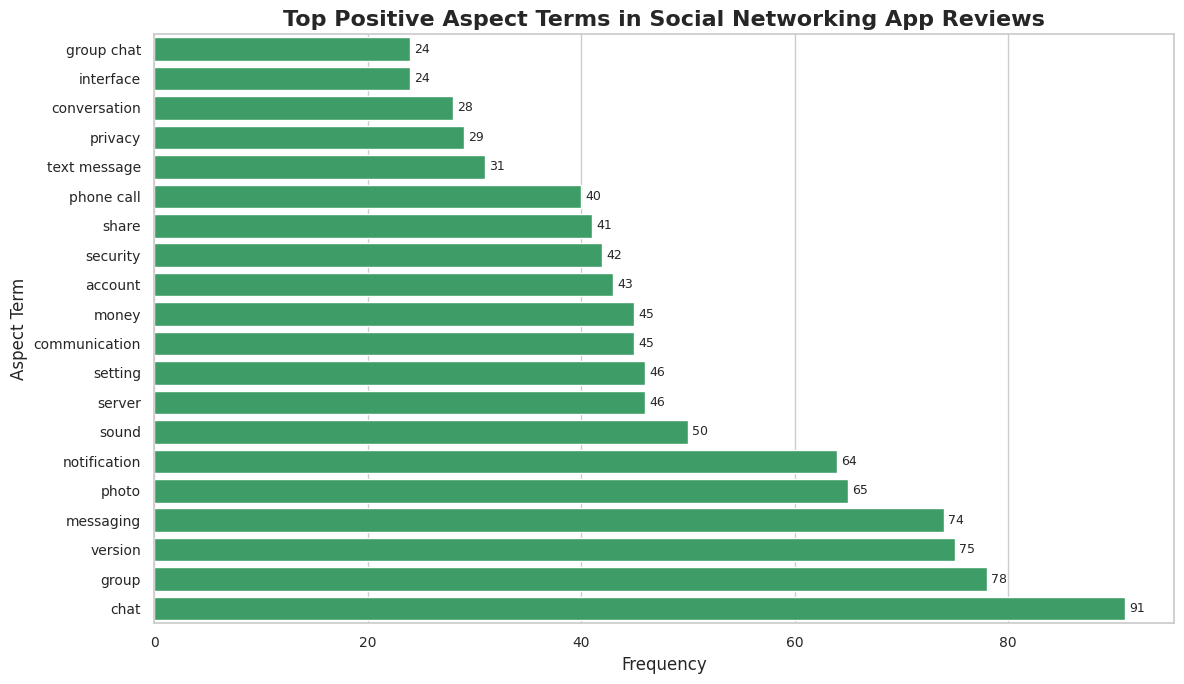

In [ ]:
# This chart shows the aspect terms most frequently linked
# with positive sentiment.
#
# Assignment usage:
# - Report-ready visual for Opinion Mining and ABSA
# ============================================================

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_positive_aspect_terms.sort_values("Frequency", ascending=True),
    x="Frequency",
    y="Aspect Term",
    color=SENTIMENT_COLORS["positive"]
)

plt.title("Top Positive Aspect Terms in Social Networking App Reviews")
plt.xlabel("Frequency")
plt.ylabel("Aspect Term")

add_bar_labels(ax)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/top_positive_aspect_terms.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Top Negative Aspect Terms Chart**

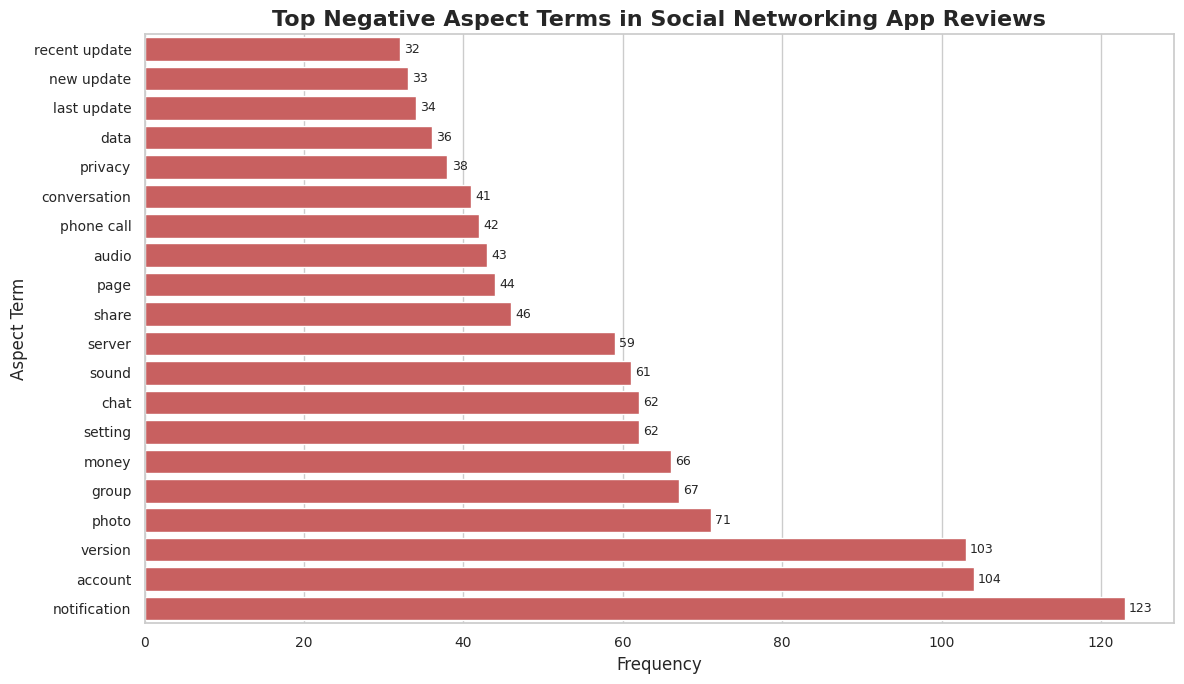

In [ ]:
# This chart shows the aspect terms most frequently linked
# with negative sentiment.
#
# Assignment usage:
# - Report-ready visual for Opinion Mining and ABSA
# ============================================================

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_negative_aspect_terms.sort_values("Frequency", ascending=True),
    x="Frequency",
    y="Aspect Term",
    color=SENTIMENT_COLORS["negative"]
)

plt.title("Top Negative Aspect Terms in Social Networking App Reviews")
plt.xlabel("Frequency")
plt.ylabel("Aspect Term")

add_bar_labels(ax)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/top_negative_aspect_terms.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Aspect Term Sentiment Comparison Table**

In [ ]:
# This table compares positive and negative sentiment counts
# for the most frequent aspect terms.
#
# Why this is stronger than word clouds:
# - It shows whether an aspect is mostly praised or criticized.
# - It shows mixed opinions clearly.
#
# Assignment usage:
# - Strong ABSA result table
# - Useful for Discussion section
# ============================================================

# Select top 20 terms by total frequency
top_terms = (
    aspect_terms_filtered_df["term_clean"]
    .value_counts()
    .head(20)
    .index
)

top_terms_df = aspect_terms_filtered_df[
    aspect_terms_filtered_df["term_clean"].isin(top_terms)
].copy()

term_sentiment_comparison = pd.crosstab(
    top_terms_df["term_clean"],
    top_terms_df["sentiment"]
)

# Ensure both sentiment columns exist
for col in ["positive", "negative"]:
    if col not in term_sentiment_comparison.columns:
        term_sentiment_comparison[col] = 0

term_sentiment_comparison = term_sentiment_comparison[["positive", "negative"]]

term_sentiment_comparison["total"] = (
    term_sentiment_comparison["positive"] +
    term_sentiment_comparison["negative"]
)

term_sentiment_comparison["negative_percentage"] = (
    term_sentiment_comparison["negative"] /
    term_sentiment_comparison["total"] * 100
).round(2)

term_sentiment_comparison = term_sentiment_comparison.sort_values(
    by="total",
    ascending=False
)

term_sentiment_comparison.to_csv(
    "results_notebook2/top_aspect_terms_sentiment_comparison.csv"
)

term_sentiment_comparison

sentiment,positive,negative,total,negative_percentage
term_clean,,,,
notification,64,123,187,65.78
version,75,103,178,57.87
chat,91,62,153,40.52
account,43,104,147,70.75
group,78,67,145,46.21
photo,65,71,136,52.21
sound,50,61,111,54.95
money,45,66,111,59.46
setting,46,62,108,57.41


# **Aspect Term Sentiment Comparison Chart**

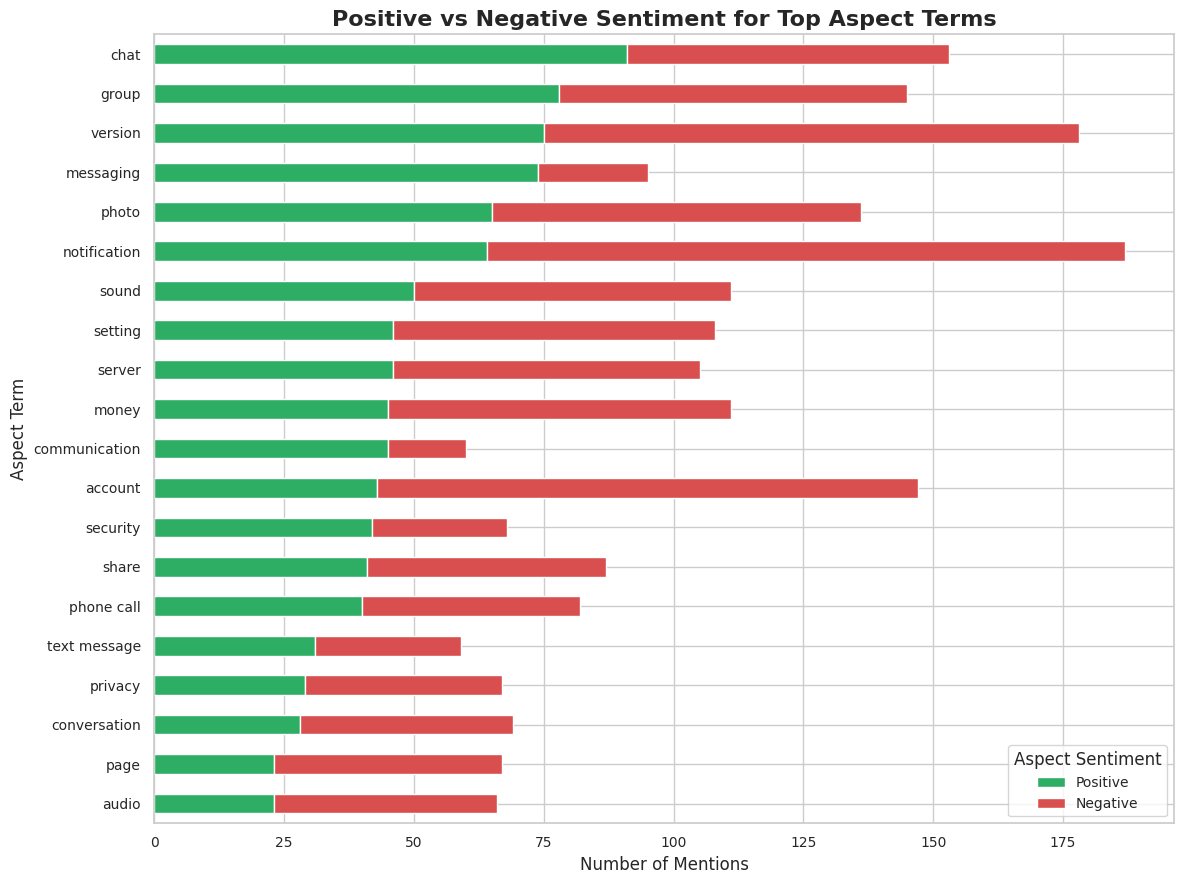

In [ ]:
# This stacked bar chart shows positive vs negative sentiment
# for the most frequent aspect terms.
#
# Assignment usage:
# - Main report visual candidate
# - Shows mixed opinions clearly
# ============================================================

plot_df = term_sentiment_comparison[["positive", "negative"]].sort_values(
    by=["positive", "negative"],
    ascending=True
)

plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 9),
    color=[
        SENTIMENT_COLORS["positive"],
        SENTIMENT_COLORS["negative"]
    ]
)

plt.title("Positive vs Negative Sentiment for Top Aspect Terms")
plt.xlabel("Number of Mentions")
plt.ylabel("Aspect Term")
plt.legend(title="Aspect Sentiment", labels=["Positive", "Negative"], loc="lower right")

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/top_aspect_terms_sentiment_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **High-Risk Negative Aspect Terms Table**

In [ ]:
# This cell identifies aspect terms with the highest negative
# sentiment percentage.
#
# To avoid misleading results, only terms mentioned at least
# 8 times are included.
#
# Assignment usage:
# - Strong evidence for Discussion section
# - Identifies problematic app features
# ============================================================

term_risk_table = pd.crosstab(
    aspect_terms_filtered_df["term_clean"],
    aspect_terms_filtered_df["sentiment"]
)

for col in ["positive", "negative"]:
    if col not in term_risk_table.columns:
        term_risk_table[col] = 0

term_risk_table = term_risk_table[["positive", "negative"]]

term_risk_table["total"] = (
    term_risk_table["positive"] +
    term_risk_table["negative"]
)

term_risk_table["negative_percentage"] = (
    term_risk_table["negative"] /
    term_risk_table["total"] * 100
).round(2)

# Only keep terms with at least 8 mentions
high_risk_negative_terms = term_risk_table[
    term_risk_table["total"] >= 8
].sort_values(
    by=["negative_percentage", "total"],
    ascending=[False, False]
).head(15)

high_risk_negative_terms.to_csv(
    "results_notebook2/high_risk_negative_aspect_terms.csv"
)

high_risk_negative_terms

sentiment,positive,negative,total,negative_percentage
term_clean,,,,
loading screen,0,9,9,100.00
last update,3,34,37,91.89
customer support,2,10,12,83.33
news feed,2,10,12,83.33
volume,7,28,35,80.00
account,43,104,147,70.75
voice chat,7,16,23,69.57
news,11,25,36,69.44
content,8,17,25,68.00


# **High-Risk Negative Aspect Terms Chart**

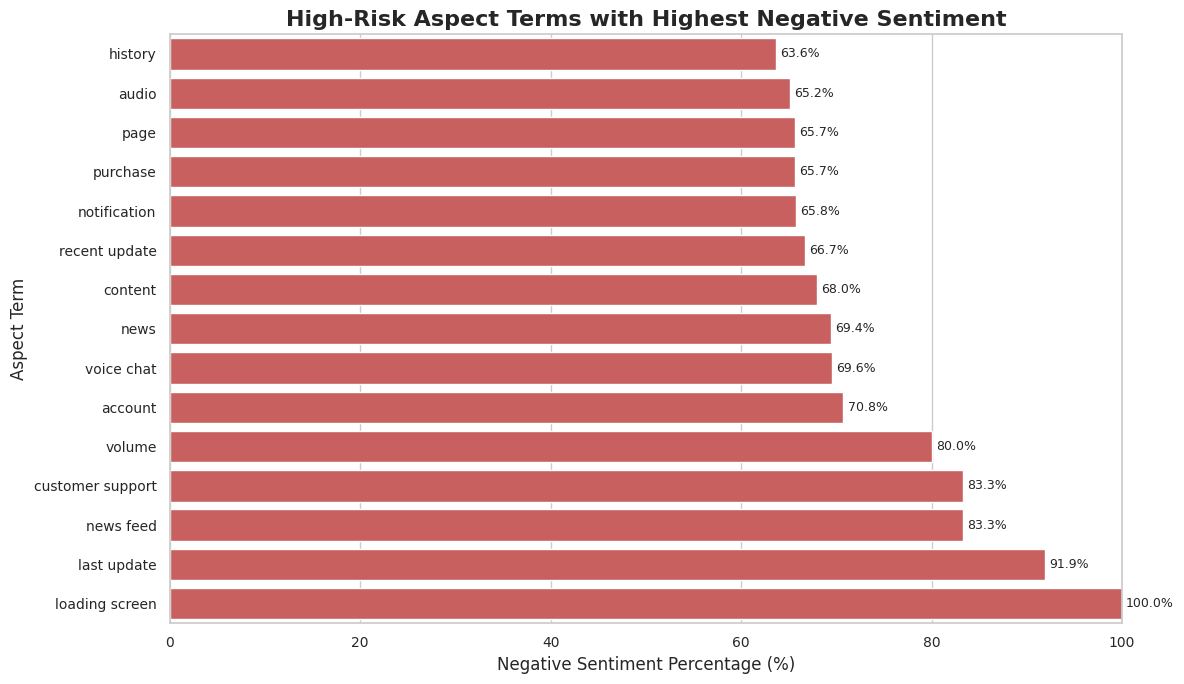

In [ ]:
# This chart highlights aspect terms with the highest negative
# sentiment percentage.
#
# Assignment usage:
# - Main report visual candidate
# - Strong discussion evidence
# ============================================================

high_risk_plot_df = high_risk_negative_terms.sort_values(
    by="negative_percentage",
    ascending=True
).reset_index()

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=high_risk_plot_df,
    x="negative_percentage",
    y="term_clean",
    color=SENTIMENT_COLORS["negative"]
)

plt.title("High-Risk Aspect Terms with Highest Negative Sentiment")
plt.xlabel("Negative Sentiment Percentage (%)")
plt.ylabel("Aspect Term")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

plt.xlim(0, 100)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/high_risk_negative_aspect_terms.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **App-Level High-Risk Aspect Term Table**

In [ ]:
# This cell identifies which apps are associated with the
# high-risk negative aspect terms.
#
# Assignment usage:
# - Provides app-specific ABSA insight
# - Useful for Discussion section
# ============================================================

high_risk_term_list = high_risk_negative_terms.index.tolist()

app_high_risk_terms = aspect_terms_filtered_df[
    (aspect_terms_filtered_df["term_clean"].isin(high_risk_term_list)) &
    (aspect_terms_filtered_df["sentiment"] == "negative")
].copy()

app_high_risk_summary = pd.crosstab(
    app_high_risk_terms["app"],
    app_high_risk_terms["term_clean"]
)

app_high_risk_summary.to_csv(
    "results_notebook2/app_high_risk_negative_terms.csv"
)

app_high_risk_summary

term_clean,account,audio,content,customer support,history,last update,loading screen,news,news feed,notification,page,purchase,recent update,voice chat,volume
app,,,,,,,,,,,,,,,
discord,28,10,2,0,3,1,8,0,0,32,2,2,14,16,4
facebook,31,1,11,0,1,8,0,24,10,35,28,0,7,0,2
free-tone-calling-texting,24,3,1,2,4,6,1,0,0,33,11,13,4,0,0
teamspeak-3,1,9,0,1,0,10,0,1,0,1,0,4,3,0,20
threema-the-secure-messenger,3,7,1,0,2,4,0,0,0,1,0,1,1,0,1
whatsapp-messenger,17,13,2,7,4,5,0,0,0,21,3,3,3,0,1


# **App-Level High-Risk Aspect Heatmap**

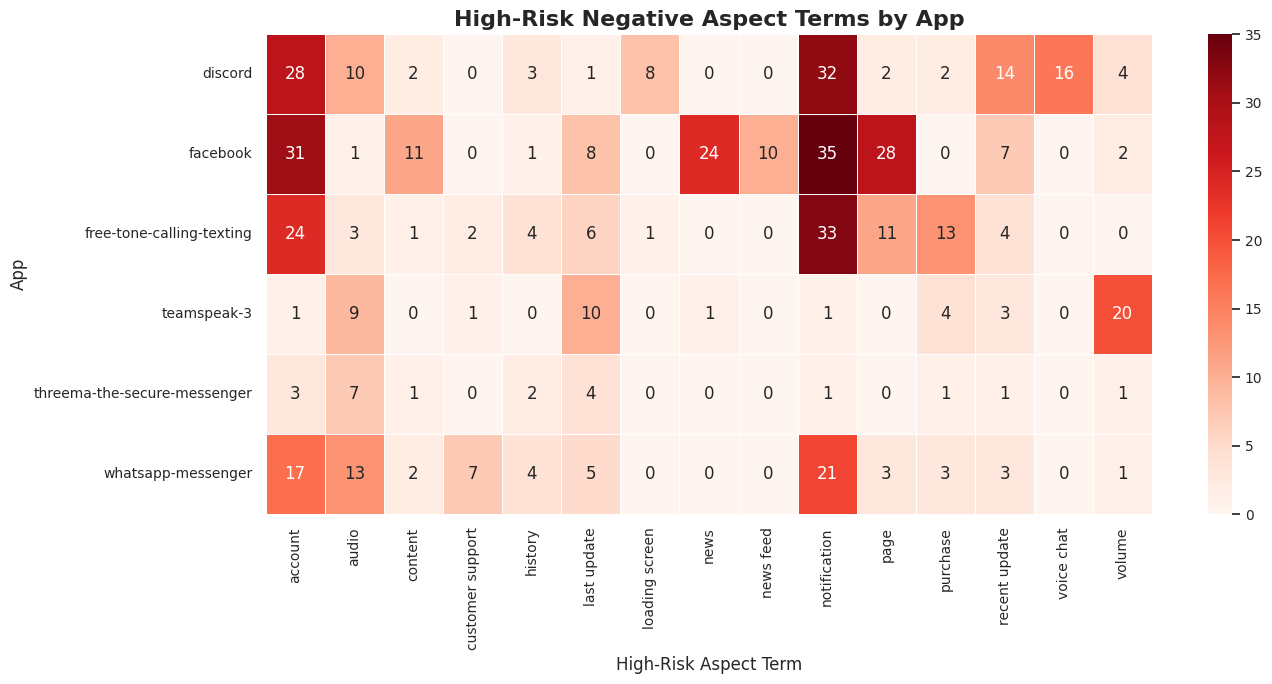

In [ ]:
# This heatmap shows which apps are most associated with
# high-risk negative aspect terms.
#
# Assignment usage:
# - Strong app-specific ABSA visualization
# - Useful for report and presentation
# ============================================================

plt.figure(figsize=(14, 7))

sns.heatmap(
    app_high_risk_summary,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white"
)

plt.title("High-Risk Negative Aspect Terms by App")
plt.xlabel("High-Risk Aspect Term")
plt.ylabel("App")

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/app_high_risk_negative_terms_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 5. Custom Opinion Word Extraction

Phase 2 identified the **aspect terms** users discuss, such as `notification`, `account`, `version`, `chat`, and `server`.

However, aspect terms are not always sentiment words. For example:

| Aspect Term | Meaning |
|---|---|
| `account` | A feature or topic |
| `notification` | A feature or topic |
| `server` | A technical feature |
| `chat` | A communication feature |

To perform more accurate **opinion mining**, this phase extracts actual positive and negative **opinion words**, such as:

| Positive Opinion Words | Negative Opinion Words |
|---|---|
| easy | annoying |
| smooth | broken |
| useful | crash |
| reliable | slow |
| secure | frustrating |

This phase uses a custom social networking app review lexicon to separate:

1. **Aspect terms** — what users are talking about  
2. **Opinion words** — how users feel about those aspects  

These outputs support the **Opinion Mining**, **Result & Visualization**, and **Discussion** sections of the final report.

# **Define Custom Opinion Lexicon**

In [ ]:
positive_opinion_words = {
    # General positive sentiment
    "good", "great", "excellent", "amazing", "awesome", "perfect",
    "nice", "best", "better", "love", "loved", "like", "liked",

    # Usability and usefulness
    "useful", "helpful", "easy", "easier", "simple", "convenient",
    "friendly", "intuitive", "clear", "clean",

    # Performance and reliability
    "smooth", "fast", "quick", "stable", "reliable", "responsive",
    "efficient", "effective", "works", "working", "fine",

    # Security and value
    "secure", "safe", "private", "free", "worth", "valuable",

    # Enjoyability
    "cool", "fun", "enjoy", "enjoyable", "impressive",
    "recommend", "recommended"
}

negative_opinion_words = {
    # General negative sentiment
    "bad", "poor", "terrible", "awful", "worst", "hate", "hated",
    "annoying", "frustrating", "useless", "disappointed",
    "disappointing", "horrible", "worse",

    # Difficulty and confusion
    "difficult", "hard", "confusing", "limited", "missing",

    # Performance problems
    "slow", "lag", "lags", "laggy", "freeze", "freezes", "frozen",
    "crash", "crashes", "crashed", "crashing",

    # Bugs and errors
    "bug", "bugs", "buggy", "broken", "break", "breaks",
    "fail", "fails", "failed", "failure", "error", "errors",
    "issue", "issues", "problem", "problems",

    # Trust, safety, cost, and unwanted behavior
   "unusable", "unreliable", "unsafe", "insecure", "expensive",
    "costly", "blocked", "lost", "delete", "deleted", "spam",
    "scam", "ads", "advertisement", "interrupt",
    "delayed", "delay"
}

print("Positive opinion words:", len(positive_opinion_words))
print("Negative opinion words:", len(negative_opinion_words))

Positive opinion words: 47
Negative opinion words: 63


# **Extract Custom Opinion Words from Sentences**

In [ ]:
# This cell scans each aspect-level sentence and extracts words
# that match the custom positive/negative opinion lexicon.
#
# New columns created:
# - matched_positive_words
# - matched_negative_words
# - opinion_words_found
#
# Assignment usage:
# - Provides clear opinion mining evidence
# - Helps separate feature mentions from sentiment expressions
# ============================================================

def extract_custom_opinion_words(text):
    words = str(text).lower().split()

    matched_positive = []
    matched_negative = []

    for word in words:
        word = word.strip()

        if word in positive_opinion_words:
            matched_positive.append(word)

        if word in negative_opinion_words:
            matched_negative.append(word)

    return matched_positive, matched_negative


opinion_extraction_results = aspect_df["basic_clean_sentence"].apply(
    extract_custom_opinion_words
)

aspect_df["matched_positive_words"] = opinion_extraction_results.apply(lambda x: x[0])
aspect_df["matched_negative_words"] = opinion_extraction_results.apply(lambda x: x[1])

aspect_df["opinion_words_found"] = aspect_df.apply(
    lambda row: row["matched_positive_words"] + row["matched_negative_words"],
    axis=1
)

aspect_df[
    [
        "sentence",
        "sentiment",
        "matched_positive_words",
        "matched_negative_words",
        "opinion_words_found"
    ]
].head(10)

,sentence,sentiment,matched_positive_words,matched_negative_words,opinion_words_found
0,I just drained about 15-20 percent of my phone...,negative,[better],[],[better]
1,"On an iPad Pro, I would honestly expect somewa...",negative,[],[],[]
2,Would be awesome if you could press the volume...,negative,[awesome],[problem],"[awesome, problem]"
3,I've always had trouble with the alerts not wo...,negative,[working],[],[working]
4,But the mobile recent update just killed it.,negative,[],[],[]
5,I’m an IT professional it appears the app is i...,negative,[],[issues],[issues]
6,I’m an IT professional it appears the app is i...,negative,[],[issues],[issues]
7,However... getting added to group chats is so ...,negative,[],[annoying],[annoying]
8,I love status updates too.,positive,[love],[],[love]
9,I mean the update description has been the sam...,negative,[],[],[]


# **Count Custom Opinion Words**

In [ ]:
# This cell counts all extracted positive and negative opinion
# words across the aspect-level dataset.
#
# These results are more meaningful than general word frequency
# because they are restricted to sentiment-bearing words.
# ============================================================

all_positive_opinion_words = []
all_negative_opinion_words = []

for words in aspect_df["matched_positive_words"]:
    all_positive_opinion_words.extend(words)

for words in aspect_df["matched_negative_words"]:
    all_negative_opinion_words.extend(words)

custom_positive_word_counts = Counter(all_positive_opinion_words)
custom_negative_word_counts = Counter(all_negative_opinion_words)

custom_positive_words_df = pd.DataFrame(
    custom_positive_word_counts.most_common(25),
    columns=["Positive Opinion Word", "Frequency"]
)

custom_negative_words_df = pd.DataFrame(
    custom_negative_word_counts.most_common(25),
    columns=["Negative Opinion Word", "Frequency"]
)

custom_positive_words_df.to_csv(
    "results_notebook2/custom_positive_opinion_words.csv",
    index=False
)

custom_negative_words_df.to_csv(
    "results_notebook2/custom_negative_opinion_words.csv",
    index=False
)

print("Custom positive opinion words:")
display(custom_positive_words_df)

print("\nCustom negative opinion words:")
display(custom_negative_words_df)

Custom positive opinion words:


,Positive Opinion Word,Frequency
0,like,230
1,great,114
2,love,87
3,free,70
4,good,59
5,works,54
6,better,42
7,easy,40
8,best,36
9,clear,28



Custom negative opinion words:


,Negative Opinion Word,Frequency
0,problem,67
1,ads,38
2,issues,36
3,issue,30
4,problems,28
5,delete,28
6,annoying,23
7,lost,16
8,bugs,15
9,deleted,15


# **Positive Opinion Words Chart**

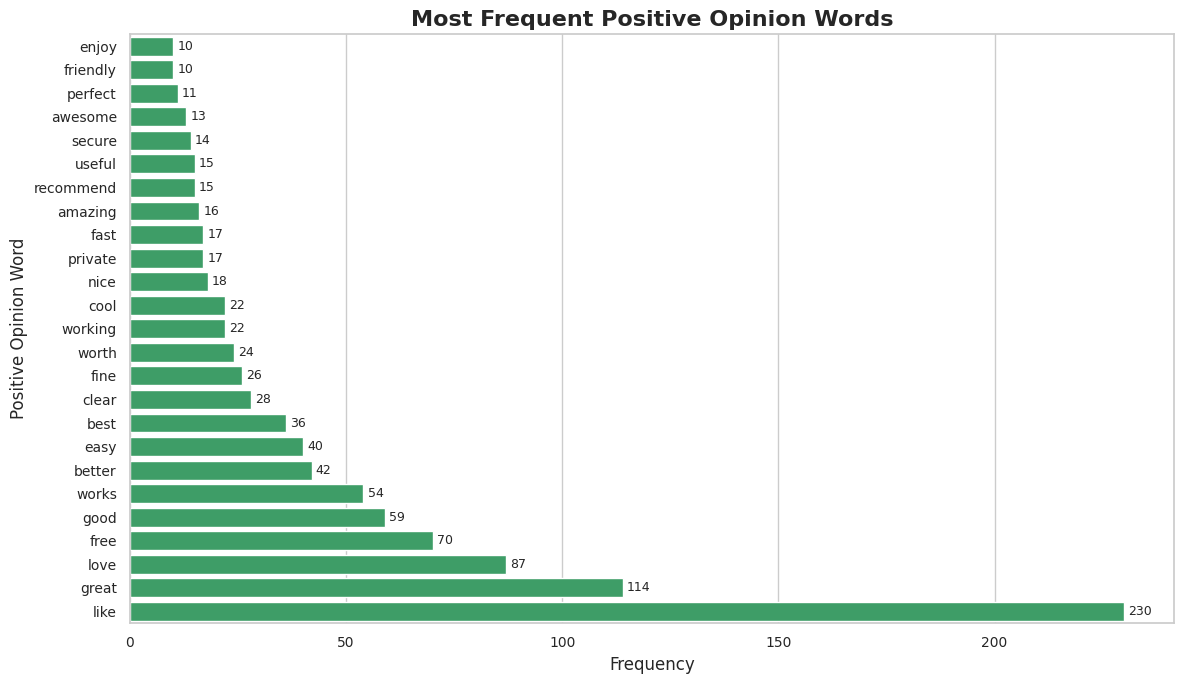

In [ ]:
# This chart shows the most frequent positive opinion words
# extracted using the custom lexicon.
#
# Assignment usage:
# - Report-ready opinion mining visual
# - Shows how users express satisfaction
# ============================================================

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=custom_positive_words_df.sort_values("Frequency", ascending=True),
    x="Frequency",
    y="Positive Opinion Word",
    color=SENTIMENT_COLORS["positive"]
)

plt.title("Most Frequent Positive Opinion Words")
plt.xlabel("Frequency")
plt.ylabel("Positive Opinion Word")

add_bar_labels(ax)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/custom_positive_opinion_words.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Negative Opinion Words Chart**

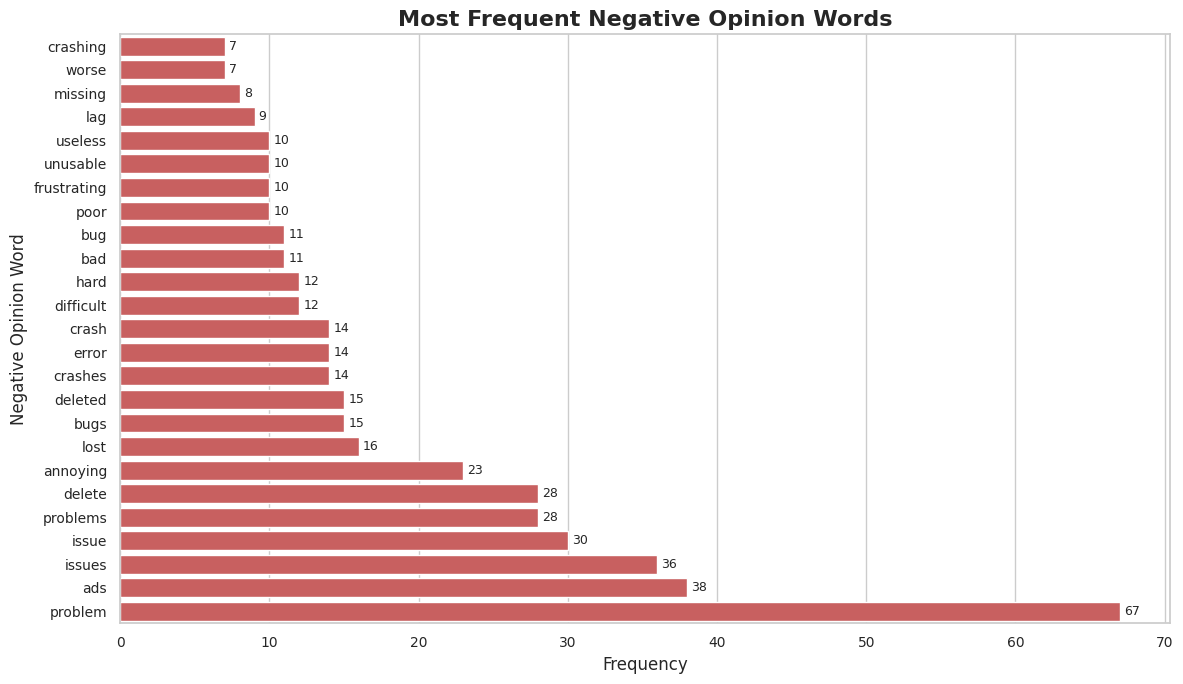

In [ ]:
# This chart shows the most frequent negative opinion words
# extracted using the custom lexicon.
#
# Assignment usage:
# - Report-ready opinion mining visual
# - Shows how users express dissatisfaction
# ============================================================

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=custom_negative_words_df.sort_values("Frequency", ascending=True),
    x="Frequency",
    y="Negative Opinion Word",
    color=SENTIMENT_COLORS["negative"]
)

plt.title("Most Frequent Negative Opinion Words")
plt.xlabel("Frequency")
plt.ylabel("Negative Opinion Word")

add_bar_labels(ax)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/custom_negative_opinion_words.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Opinion Word Coverage Table**

In [ ]:
# This cell checks how many aspect-level sentences contain at
# least one custom opinion word.
#
# Why this matters:
# If many sentences do not contain custom opinion words, it means
# the sentiment is often implicit or context-dependent.
#
# Assignment usage:
# - Supports explicit/implicit opinion discussion
# - Explains why ML/transformer models are useful
# ============================================================

aspect_df["has_custom_opinion_word"] = aspect_df["opinion_words_found"].apply(
    lambda x: len(x) > 0
)

custom_opinion_coverage = (
    aspect_df["has_custom_opinion_word"]
    .value_counts()
    .reset_index()
)

custom_opinion_coverage.columns = ["Has Custom Opinion Word", "Count"]

custom_opinion_coverage["Percentage"] = (
    custom_opinion_coverage["Count"] /
    custom_opinion_coverage["Count"].sum() * 100
).round(2)

custom_opinion_coverage.to_csv(
    "results_notebook2/custom_opinion_word_coverage.csv",
    index=False
)

custom_opinion_coverage

,Has Custom Opinion Word,Count,Percentage
0,False,1829,59.06
1,True,1268,40.94


# **Opinion Word Coverage Chart**

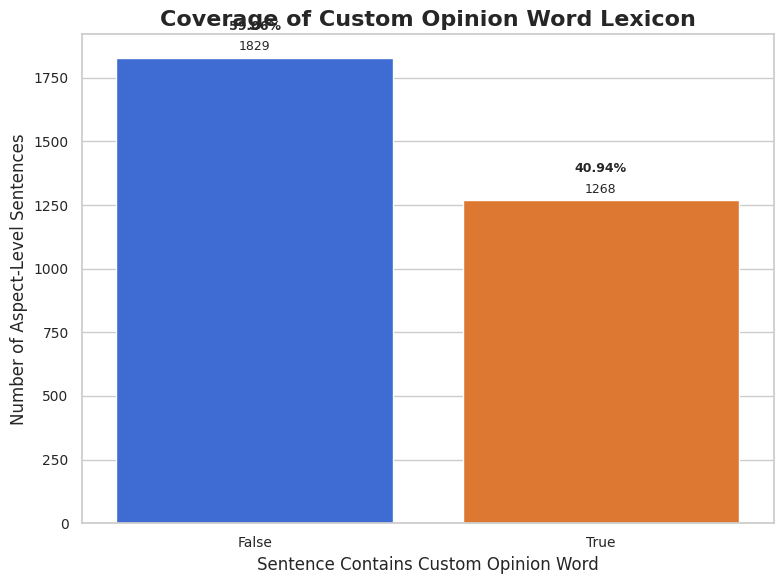

In [ ]:
# This chart shows the percentage of sentences that contain
# custom opinion words.
#
# Assignment usage:
# - Helps explain explicit vs implicit sentiment
# - Useful for Discussion section
# ============================================================

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=custom_opinion_coverage,
    x="Has Custom Opinion Word",
    y="Count",
    palette=[MAIN_BLUE, MAIN_ORANGE]
)

plt.title("Coverage of Custom Opinion Word Lexicon")
plt.xlabel("Sentence Contains Custom Opinion Word")
plt.ylabel("Number of Aspect-Level Sentences")

add_bar_labels(ax)

for i, row in custom_opinion_coverage.iterrows():
    ax.text(
        i,
        row["Count"] + custom_opinion_coverage["Count"].max() * 0.06,
        f'{row["Percentage"]}%',
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/custom_opinion_word_coverage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Opinion Words by Dataset Sentiment**

In [ ]:
# This table checks how opinion-word coverage differs between
# positive and negative aspect sentiment labels.
#
# Assignment usage:
# - Helps explain whether positive/negative labels contain
#   direct opinion expressions or contextual sentiment.
# ============================================================

opinion_word_by_sentiment = pd.crosstab(
    aspect_df["sentiment"],
    aspect_df["has_custom_opinion_word"]
)

opinion_word_by_sentiment.to_csv(
    "results_notebook2/opinion_word_coverage_by_sentiment.csv"
)

opinion_word_by_sentiment

has_custom_opinion_word,False,True
sentiment,,
negative,1094,621
positive,735,647


# **Opinion Words by Sentiment Heatmap**

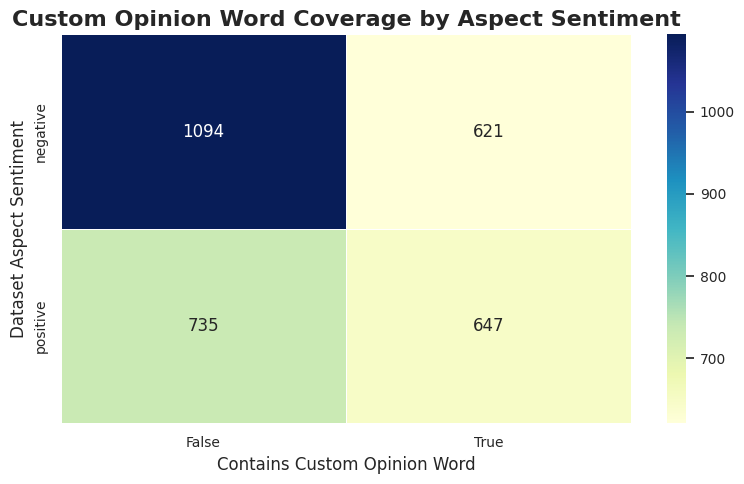

In [ ]:
# This heatmap shows whether positive and negative sentiment
# sentences contain custom opinion words.
# ============================================================

plt.figure(figsize=(8, 5))

sns.heatmap(
    opinion_word_by_sentiment,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Custom Opinion Word Coverage by Aspect Sentiment")
plt.xlabel("Contains Custom Opinion Word")
plt.ylabel("Dataset Aspect Sentiment")

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/opinion_word_coverage_by_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Examples With and Without Custom Opinion Words**

In [ ]:
# This cell extracts example sentences for report explanation.
#
# Assignment usage:
# - Helps explain explicit/contextual opinion expressions
# - Useful for Discussion section
# ============================================================

examples_with_opinion_words = aspect_df[
    aspect_df["has_custom_opinion_word"] == True
][
    [
        "sentence",
        "category",
        "term",
        "sentiment",
        "matched_positive_words",
        "matched_negative_words"
    ]
].head(15)

examples_without_opinion_words = aspect_df[
    aspect_df["has_custom_opinion_word"] == False
][
    [
        "sentence",
        "category",
        "term",
        "sentiment"
    ]
].head(15)

examples_with_opinion_words.to_csv(
    "results_notebook2/examples_with_custom_opinion_words.csv",
    index=False
)

examples_without_opinion_words.to_csv(
    "results_notebook2/examples_without_custom_opinion_words.csv",
    index=False
)

print("Examples with extracted opinion words:")
display(examples_with_opinion_words)

print("\nExamples without extracted opinion words:")
display(examples_without_opinion_words)

Examples with extracted opinion words:


,sentence,category,term,sentiment,matched_positive_words,matched_negative_words
0,I just drained about 15-20 percent of my phone...,efficiency,video call,negative,[better],[]
2,Would be awesome if you could press the volume...,usability,volume,negative,[awesome],[problem]
3,I've always had trouble with the alerts not wo...,reliability,phone call,negative,[working],[]
5,I’m an IT professional it appears the app is i...,reliability,volume,negative,[],[issues]
6,I’m an IT professional it appears the app is i...,reliability,server,negative,[],[issues]
7,However... getting added to group chats is so ...,usability,group chat,negative,[],[annoying]
8,I love status updates too.,general,status update,positive,[love],[]
12,You have to pay for the ad free version on top...,cost,version,negative,[free],[]
13,The interface is super user friendly for newbi...,usability,interface,positive,[friendly],[lag]
16,Because of the stupid way a discord call acts ...,general,phone call,negative,[like],[]



Examples without extracted opinion words:


,sentence,category,term,sentiment
1,"On an iPad Pro, I would honestly expect somewa...",effectiveness,share,negative
4,But the mobile recent update just killed it.,general,recent update,negative
9,I mean the update description has been the sam...,general,version,negative
10,Especially not without the consent of the send...,security,unknown_term,negative
11,Sometime between the last time I managed my gr...,reliability,group,negative
14,Everyone loves WhatsApp but we need privacy !!!,security,privacy,negative
15,Using the IPhone 6s this app closes out the sp...,effectiveness,speaker,negative
17,I have reported a total of 15 accounts that ar...,safety,account,negative
18,"In order to stop them, you have to mute everyt...",effectiveness,notification,negative
19,The iPhone version has ‘Most Recent’ where it ...,general,version,positive


# 6. VADER Lexicon-Based Sentiment Comparison

This phase applies VADER sentiment analysis to the aspect-level sentences.

VADER is a lexicon-based sentiment analysis tool. It assigns a compound sentiment score based on predefined sentiment words and rules.

In this project, VADER is used only as a **baseline comparison**, not as the final model.

The goal is to compare:

1. Dataset-provided aspect sentiment labels  
2. VADER lexicon-based sentiment labels  

This comparison helps explain why machine learning and transformer models are needed. Lexicon-based methods may miss context, sarcasm, mixed opinions, or aspect-specific meaning.

# **Apply VADER Sentiment Scoring**

In [ ]:
# This cell applies VADER sentiment analysis to each sentence.
#
# VADER output:
# - compound score from -1 to +1
# - positive, neutral, or negative label based on threshold
#
# Assignment usage:
# - Supports Opinion Mining
# - Provides a lexicon-based sentiment baseline
# - Helps explain limitations of rule-based sentiment methods
# ============================================================

sia = SentimentIntensityAnalyzer()

aspect_df["vader_compound"] = aspect_df["sentence"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

def vader_sentiment_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

aspect_df["vader_sentiment"] = aspect_df["vader_compound"].apply(
    vader_sentiment_label
)

aspect_df[
    [
        "sentence",
        "category",
        "term",
        "sentiment",
        "vader_compound",
        "vader_sentiment"
    ]
].head(10)

,sentence,category,term,sentiment,vader_compound,vader_sentiment
0,I just drained about 15-20 percent of my phone...,efficiency,video call,negative,0.1027,positive
1,"On an iPad Pro, I would honestly expect somewa...",effectiveness,share,negative,0.7845,positive
2,Would be awesome if you could press the volume...,usability,volume,negative,-0.2500,negative
3,I've always had trouble with the alerts not wo...,reliability,phone call,negative,-0.4019,negative
4,But the mobile recent update just killed it.,general,recent update,negative,-0.8047,negative
5,I’m an IT professional it appears the app is i...,reliability,volume,negative,-0.3818,negative
6,I’m an IT professional it appears the app is i...,reliability,server,negative,-0.3818,negative
7,However... getting added to group chats is so ...,usability,group chat,negative,-0.5836,negative
8,I love status updates too.,general,status update,positive,0.6369,positive
9,I mean the update description has been the sam...,general,version,negative,0.0000,neutral


# **VADER Sentiment Distribution**

In [ ]:
# This cell shows how VADER classifies the aspect-level sentences.
#
# Assignment usage:
# - Shows the difference between lexicon-based sentiment
#   and dataset-provided aspect sentiment.
# ============================================================

vader_sentiment_summary = (
    aspect_df["vader_sentiment"]
    .value_counts()
    .reindex(["positive", "neutral", "negative"])
    .reset_index()
)

vader_sentiment_summary.columns = ["VADER Sentiment", "Count"]

vader_sentiment_summary["Percentage"] = (
    vader_sentiment_summary["Count"] /
    vader_sentiment_summary["Count"].sum() * 100
).round(2)

vader_sentiment_summary.to_csv(
    "results_notebook2/vader_sentiment_distribution.csv",
    index=False
)

vader_sentiment_summary

,VADER Sentiment,Count,Percentage
0,positive,1412,45.59
1,neutral,923,29.80
2,negative,762,24.60


# **VADER Sentiment Distribution Chart**

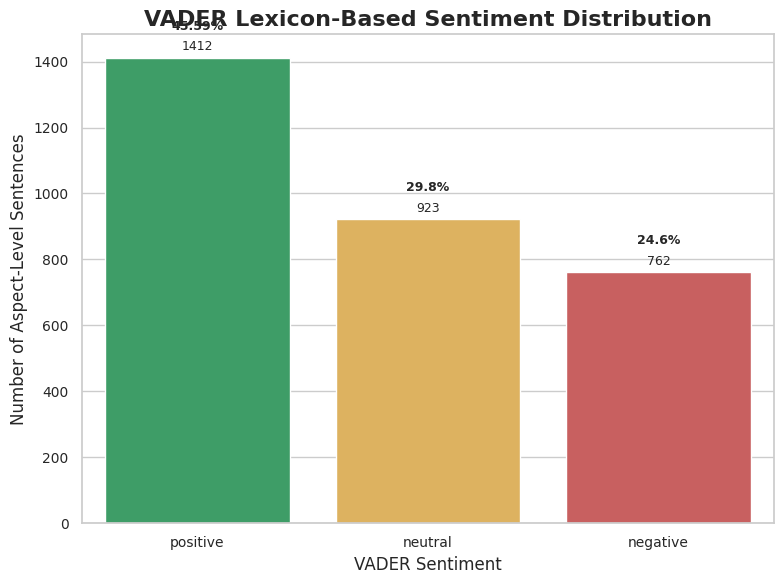

In [ ]:
# This chart visualizes VADER's sentiment label distribution.
#
# Assignment usage:
# - Useful for comparing lexicon-based sentiment output
#   with dataset-labelled aspect sentiment.
# ============================================================

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=vader_sentiment_summary,
    x="VADER Sentiment",
    y="Count",
    palette=[
        SENTIMENT_COLORS["positive"],
        SENTIMENT_COLORS["neutral"],
        SENTIMENT_COLORS["negative"]
    ]
)

plt.title("VADER Lexicon-Based Sentiment Distribution")
plt.xlabel("VADER Sentiment")
plt.ylabel("Number of Aspect-Level Sentences")

add_bar_labels(ax)

for i, row in vader_sentiment_summary.iterrows():
    ax.text(
        i,
        row["Count"] + vader_sentiment_summary["Count"].max() * 0.06,
        f'{row["Percentage"]}%',
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/vader_sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Dataset Aspect Sentiment vs VADER Sentiment**

In [ ]:
# This table compares dataset-provided aspect sentiment labels
# with VADER sentiment predictions.
#
# Assignment usage:
# - Shows agreement and disagreement between labelled aspect
#   sentiment and lexicon-based sentiment.
# - Supports Discussion section.
# ============================================================

vader_comparison = pd.crosstab(
    aspect_df["sentiment"],
    aspect_df["vader_sentiment"]
)

vader_comparison.to_csv(
    "results_notebook2/vader_vs_dataset_sentiment.csv"
)

vader_comparison

vader_sentiment,negative,neutral,positive
sentiment,,,
negative,618,565,532
positive,144,358,880


# **VADER Comparison Heatmap**

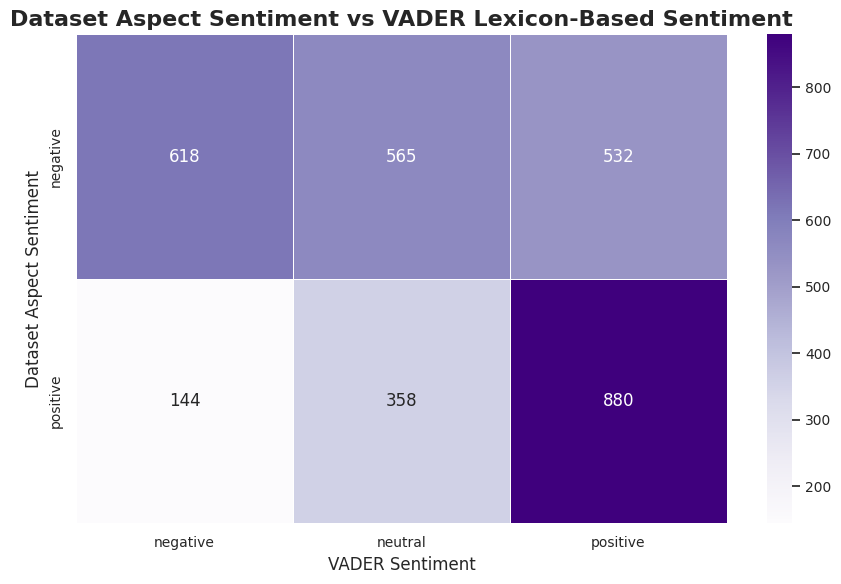

In [ ]:
# This heatmap compares dataset aspect sentiment against
# VADER lexicon-based sentiment.
#
# Assignment usage:
# - Strong visual for Discussion section
# - Shows where lexicon-based sentiment misses context
# ============================================================

plt.figure(figsize=(9, 6))

sns.heatmap(
    vader_comparison,
    annot=True,
    fmt="d",
    cmap="Purples",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Dataset Aspect Sentiment vs VADER Lexicon-Based Sentiment")
plt.xlabel("VADER Sentiment")
plt.ylabel("Dataset Aspect Sentiment")

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/vader_vs_dataset_sentiment_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Calculate VADER Agreement Rate**

In [ ]:
# This cell calculates how often VADER agrees with the dataset
# aspect sentiment labels.
#
# Since the dataset labels are only positive/negative and VADER
# can output neutral, neutral is counted as disagreement.
#
# Assignment usage:
# - Quantifies the limitation of lexicon-based sentiment analysis.
# ============================================================

aspect_df["vader_matches_dataset"] = (
    aspect_df["sentiment"] == aspect_df["vader_sentiment"]
)

vader_agreement_rate = aspect_df["vader_matches_dataset"].mean() * 100

print(f"VADER agreement rate with dataset aspect sentiment: {vader_agreement_rate:.2f}%")

vader_agreement_summary = pd.DataFrame({
    "Metric": ["VADER Agreement Rate"],
    "Percentage": [round(vader_agreement_rate, 2)]
})

vader_agreement_summary.to_csv(
    "results_notebook2/vader_agreement_rate.csv",
    index=False
)

vader_agreement_summary

VADER agreement rate with dataset aspect sentiment: 48.37%


,Metric,Percentage
0,VADER Agreement Rate,48.37


# **Extract VADER Disagreement Examples**

In [ ]:
# This cell extracts examples where VADER disagrees with the
# dataset-provided aspect sentiment.
#
# Assignment usage:
# - Useful for Discussion section
# - Shows why ML/transformer models are needed
# ============================================================

vader_disagreement_examples = aspect_df[
    aspect_df["vader_matches_dataset"] == False
][
    [
        "sentence",
        "category",
        "term",
        "sentiment",
        "vader_sentiment",
        "vader_compound"
    ]
].head(20)

vader_disagreement_examples.to_csv(
    "results_notebook2/vader_disagreement_examples.csv",
    index=False
)

vader_disagreement_examples

,sentence,category,term,sentiment,vader_sentiment,vader_compound
0,I just drained about 15-20 percent of my phone...,efficiency,video call,negative,positive,0.1027
1,"On an iPad Pro, I would honestly expect somewa...",effectiveness,share,negative,positive,0.7845
9,I mean the update description has been the sam...,general,version,negative,neutral,0.0000
10,Especially not without the consent of the send...,security,unknown_term,negative,positive,0.1262
12,You have to pay for the ad free version on top...,cost,version,negative,positive,0.5719
14,Everyone loves WhatsApp but we need privacy !!!,security,privacy,negative,positive,0.4983
15,Using the IPhone 6s this app closes out the sp...,effectiveness,speaker,negative,neutral,0.0000
17,I have reported a total of 15 accounts that ar...,safety,account,negative,neutral,0.0000
19,The iPhone version has ‘Most Recent’ where it ...,general,version,positive,neutral,0.0000
22,I can’t even share my children’s pictures bc t...,effectiveness,share,negative,positive,0.3595


# **VADER Agreement by Aspect Category**

In [ ]:
# This cell calculates VADER agreement rate for each aspect category.
#
# Assignment usage:
# - Shows which aspect categories are easier or harder for
#   lexicon-based sentiment analysis.
# ============================================================

vader_agreement_by_category = (
    aspect_df
    .groupby("category")["vader_matches_dataset"]
    .mean()
    .reset_index()
)

vader_agreement_by_category["Agreement Percentage"] = (
    vader_agreement_by_category["vader_matches_dataset"] * 100
).round(2)

vader_agreement_by_category = vader_agreement_by_category.sort_values(
    by="Agreement Percentage",
    ascending=False
)

vader_agreement_by_category = vader_agreement_by_category[
    ["category", "Agreement Percentage"]
]

vader_agreement_by_category.to_csv(
    "results_notebook2/vader_agreement_by_category.csv",
    index=False
)

vader_agreement_by_category

,category,Agreement Percentage
3,enjoyability,64.89
7,security,54.58
2,efficiency,54.01
1,effectiveness,51.72
0,cost,51.03
6,safety,45.45
8,usability,45.13
4,general,44.31
5,reliability,42.13


# **VADER Agreement by Category Chart**

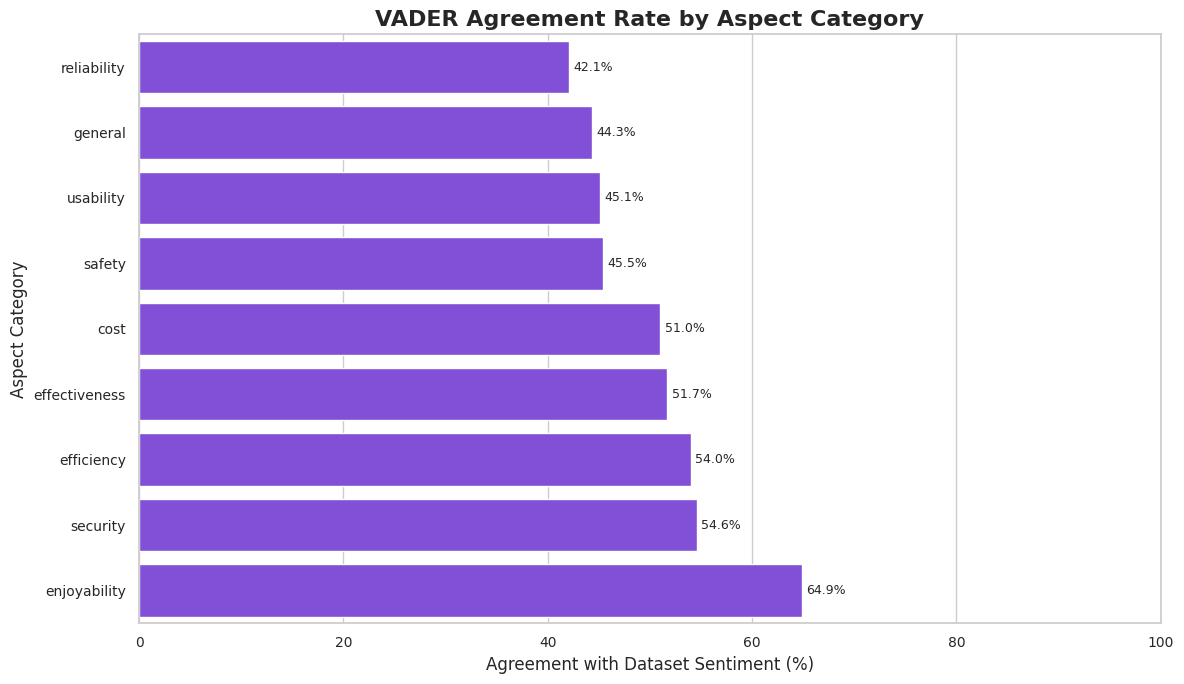

In [ ]:
# This chart shows how well VADER agrees with dataset sentiment
# across different aspect categories.
#
# Assignment usage:
# - Useful for Discussion
# - Shows category-level limitations of lexicon methods
# ============================================================

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=vader_agreement_by_category.sort_values("Agreement Percentage", ascending=True),
    x="Agreement Percentage",
    y="category",
    color=MAIN_PURPLE
)

plt.title("VADER Agreement Rate by Aspect Category")
plt.xlabel("Agreement with Dataset Sentiment (%)")
plt.ylabel("Aspect Category")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

plt.xlim(0, 100)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/vader_agreement_by_category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Save Updated Dataset with VADER Results**

In [ ]:
# This cell saves the aspect dataset after adding:
# - custom opinion word extraction columns
# - VADER compound score
# - VADER sentiment label
# - VADER agreement flag
#
# This will be used in later Notebook 2 phases and possibly Notebook 3.
# ============================================================

aspect_df.to_csv(
    "results_notebook2/aspect_level_social_reviews_with_vader.csv",
    index=False
)

print("Updated dataset saved:")
print("results_notebook2/aspect_level_social_reviews_with_vader.csv")

Updated dataset saved:
results_notebook2/aspect_level_social_reviews_with_vader.csv


# 7. Explicit vs Implicit Opinion Analysis

This phase analyses whether aspect-level opinion sentences contain direct sentiment words or whether the sentiment is expressed indirectly through context.

An **explicit opinion** contains direct sentiment-bearing words, such as:

- good
- great
- annoying
- crash
- slow
- broken

An **implicit opinion** may not contain obvious sentiment words, but still expresses positive or negative meaning through context.

Example:

| Sentence | Opinion Type | Reason |
|---|---|---|
| The app crashes every time I open it. | Explicit | Contains `crashes` |
| I have to restart the app before sending a message. | Implicit | Negative meaning is implied by context |
| The interface is easy to use. | Explicit | Contains `easy` |

This phase supports the **Opinion Mining**, **Discussion**, and **Future Work** sections of the report.

# **Create Explicit vs Implicit Opinion Labels**

In [ ]:
# This cell classifies each sentence as Explicit or Implicit.
#
# Explicit:
# - Contains at least one custom positive or negative opinion word.
#
# Implicit:
# - Does not contain a matched opinion word from the custom lexicon.
# - Sentiment may still be expressed through context.
#
# Assignment usage:
# - Supports Opinion Mining
# - Helps explain why sentiment analysis is challenging
# - Supports Discussion section
# ============================================================

aspect_df["opinion_expression_type"] = aspect_df["has_custom_opinion_word"].apply(
    lambda x: "Explicit" if x == True else "Implicit"
)

opinion_expression_summary = (
    aspect_df["opinion_expression_type"]
    .value_counts()
    .reset_index()
)

opinion_expression_summary.columns = ["Opinion Expression Type", "Count"]

opinion_expression_summary["Percentage"] = (
    opinion_expression_summary["Count"] /
    opinion_expression_summary["Count"].sum() * 100
).round(2)

opinion_expression_summary.to_csv(
    "results_notebook2/explicit_implicit_opinion_summary.csv",
    index=False
)

opinion_expression_summary

,Opinion Expression Type,Count,Percentage
0,Implicit,1829,59.06
1,Explicit,1268,40.94


# **Explicit vs Implicit Opinion Chart**

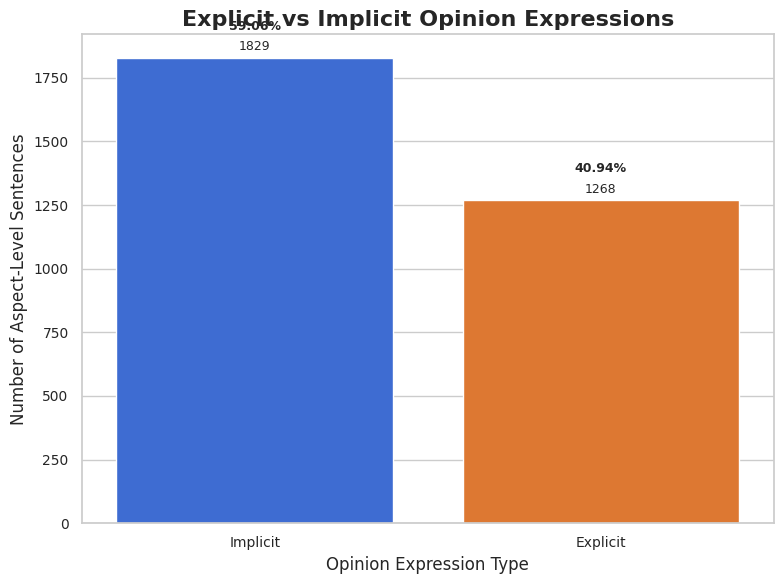

In [ ]:
# This chart shows how many aspect-level sentences contain
# direct opinion words.
#
# Assignment usage:
# - Report-ready opinion mining visual
# - Shows that many opinions are contextual rather than direct
# ============================================================

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=opinion_expression_summary,
    x="Opinion Expression Type",
    y="Count",
    palette=[MAIN_BLUE, MAIN_ORANGE]
)

plt.title("Explicit vs Implicit Opinion Expressions")
plt.xlabel("Opinion Expression Type")
plt.ylabel("Number of Aspect-Level Sentences")

add_bar_labels(ax)

for i, row in opinion_expression_summary.iterrows():
    ax.text(
        i,
        row["Count"] + opinion_expression_summary["Count"].max() * 0.06,
        f'{row["Percentage"]}%',
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/explicit_vs_implicit_opinions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Explicit vs Implicit by Aspect Sentiment**

In [ ]:
# This table checks whether positive and negative sentiment
# sentences are more explicit or implicit.
#
# Assignment usage:
# - Helps discuss whether negative feedback is direct or contextual
# - Useful for report Discussion section
# ============================================================

explicit_implicit_by_sentiment = pd.crosstab(
    aspect_df["sentiment"],
    aspect_df["opinion_expression_type"]
)

explicit_implicit_by_sentiment.to_csv(
    "results_notebook2/explicit_implicit_by_sentiment.csv"
)

explicit_implicit_by_sentiment

opinion_expression_type,Explicit,Implicit
sentiment,,
negative,621,1094
positive,647,735


# **Explicit vs Implicit by Sentiment Heatmap**

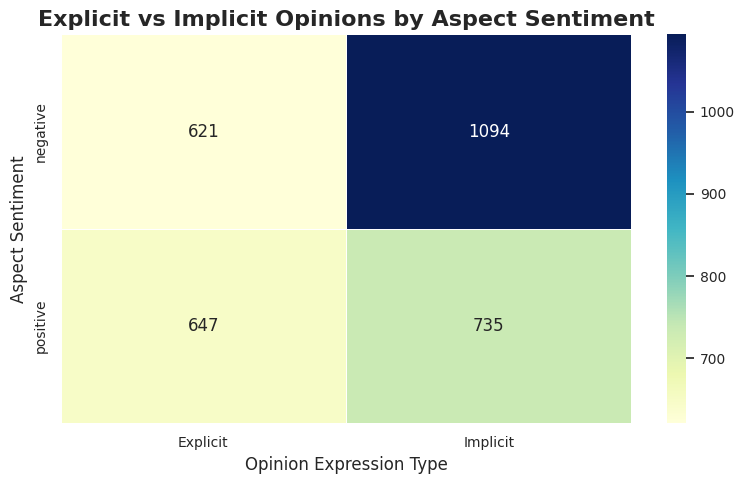

In [ ]:
# This heatmap shows explicit and implicit opinion expression
# patterns across positive and negative aspect sentiment.
# ============================================================

plt.figure(figsize=(8, 5))

sns.heatmap(
    explicit_implicit_by_sentiment,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Explicit vs Implicit Opinions by Aspect Sentiment")
plt.xlabel("Opinion Expression Type")
plt.ylabel("Aspect Sentiment")

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/explicit_implicit_by_sentiment_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Explicit vs Implicit by Aspect Category**

In [ ]:
# This table checks which aspect categories have more explicit
# or implicit opinion expressions.
#
# Assignment usage:
# - Useful for deeper ABSA discussion
# - Shows which app aspects require contextual understanding
# ============================================================

explicit_implicit_by_category = pd.crosstab(
    aspect_df["category"],
    aspect_df["opinion_expression_type"]
)

explicit_implicit_by_category["Total"] = (
    explicit_implicit_by_category.sum(axis=1)
)

if "Explicit" not in explicit_implicit_by_category.columns:
    explicit_implicit_by_category["Explicit"] = 0

if "Implicit" not in explicit_implicit_by_category.columns:
    explicit_implicit_by_category["Implicit"] = 0

explicit_implicit_by_category["Implicit Percentage"] = (
    explicit_implicit_by_category["Implicit"] /
    explicit_implicit_by_category["Total"] * 100
).round(2)

explicit_implicit_by_category = explicit_implicit_by_category.sort_values(
    by="Implicit Percentage",
    ascending=False
)

explicit_implicit_by_category.to_csv(
    "results_notebook2/explicit_implicit_by_category.csv"
)

explicit_implicit_by_category

opinion_expression_type,Explicit,Implicit,Total,Implicit Percentage
category,,,,
safety,8,25,33,75.76
general,264,492,756,65.08
security,107,177,284,62.32
usability,351,491,842,58.31
cost,82,112,194,57.73
reliability,79,99,178,55.62
enjoyability,43,51,94,54.26
efficiency,155,182,337,54.01
effectiveness,179,200,379,52.77


# **Implicit Opinion Percentage by Category Chart**

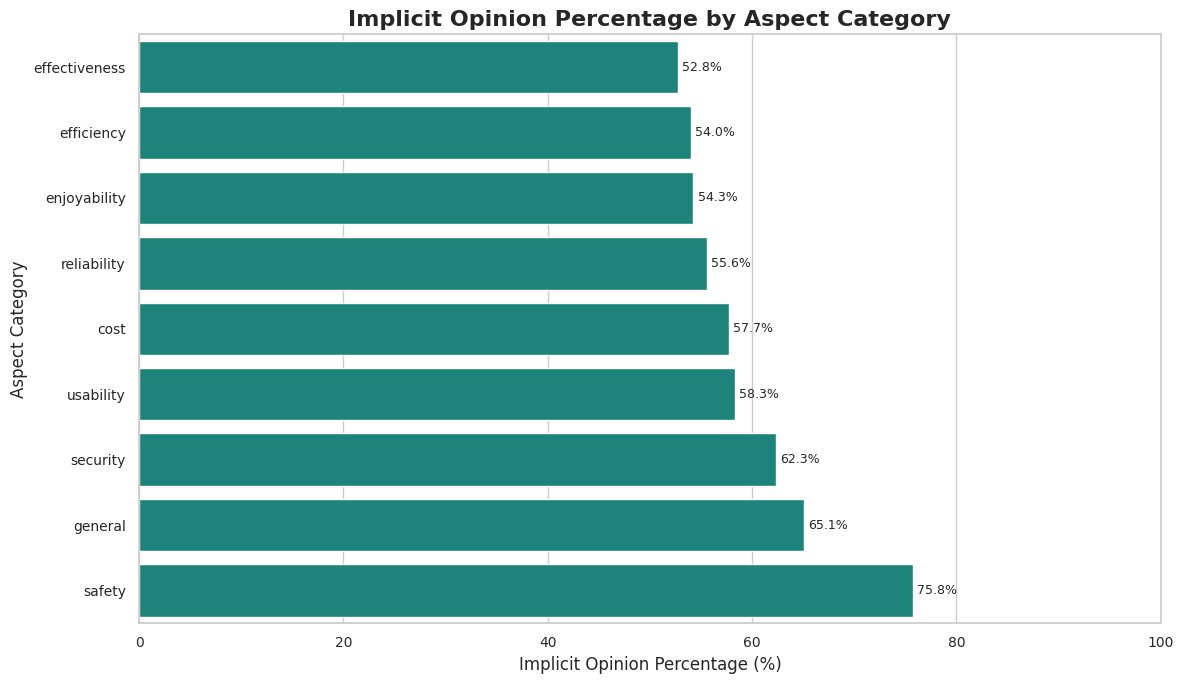

In [ ]:
# This chart shows which aspect categories have the highest
# percentage of implicit opinions.
#
# Assignment usage:
# - Strong discussion visual
# - Shows why context-aware models are important
# ============================================================

category_plot_df = explicit_implicit_by_category.reset_index()

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=category_plot_df.sort_values("Implicit Percentage", ascending=True),
    x="Implicit Percentage",
    y="category",
    color=MAIN_TEAL
)

plt.title("Implicit Opinion Percentage by Aspect Category")
plt.xlabel("Implicit Opinion Percentage (%)")
plt.ylabel("Aspect Category")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

plt.xlim(0, 100)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/implicit_opinion_percentage_by_category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Extract Explicit Opinion Examples**

In [ ]:
# This cell extracts examples of explicit opinions.
#
# Assignment usage:
# - Useful for explaining opinion mining in the report
# - Shows direct opinion words found in sentences
# ============================================================

explicit_opinion_examples = aspect_df[
    aspect_df["opinion_expression_type"] == "Explicit"
][
    [
        "app",
        "sentence",
        "category",
        "term",
        "sentiment",
        "matched_positive_words",
        "matched_negative_words"
    ]
].head(20)

explicit_opinion_examples.to_csv(
    "results_notebook2/explicit_opinion_examples.csv",
    index=False
)

explicit_opinion_examples

,app,sentence,category,term,sentiment,matched_positive_words,matched_negative_words
0,whatsapp-messenger,I just drained about 15-20 percent of my phone...,efficiency,video call,negative,[better],[]
2,teamspeak-3,Would be awesome if you could press the volume...,usability,volume,negative,[awesome],[problem]
3,free-tone-calling-texting,I've always had trouble with the alerts not wo...,reliability,phone call,negative,[working],[]
5,facebook,I’m an IT professional it appears the app is i...,reliability,volume,negative,[],[issues]
6,facebook,I’m an IT professional it appears the app is i...,reliability,server,negative,[],[issues]
7,whatsapp-messenger,However... getting added to group chats is so ...,usability,group chat,negative,[],[annoying]
8,whatsapp-messenger,I love status updates too.,general,status update,positive,[love],[]
12,free-tone-calling-texting,You have to pay for the ad free version on top...,cost,version,negative,[free],[]
13,free-tone-calling-texting,The interface is super user friendly for newbi...,usability,interface,positive,[friendly],[lag]
16,discord,Because of the stupid way a discord call acts ...,general,phone call,negative,[like],[]


# **Extract Implicit Opinion Examples**

In [ ]:
# This cell extracts examples of implicit opinions.
#
# Assignment usage:
# - Useful for explaining why context-aware ML/transformer
#   models are needed
# - Shows sentences where sentiment is not captured by simple
#   opinion-word matching
# ============================================================

implicit_opinion_examples = aspect_df[
    aspect_df["opinion_expression_type"] == "Implicit"
][
    [
        "app",
        "sentence",
        "category",
        "term",
        "sentiment",
        "vader_sentiment",
        "vader_compound"
    ]
].head(20)

implicit_opinion_examples.to_csv(
    "results_notebook2/implicit_opinion_examples.csv",
    index=False
)

implicit_opinion_examples

,app,sentence,category,term,sentiment,vader_sentiment,vader_compound
1,discord,"On an iPad Pro, I would honestly expect somewa...",effectiveness,share,negative,positive,0.7845
4,discord,But the mobile recent update just killed it.,general,recent update,negative,negative,-0.8047
9,whatsapp-messenger,I mean the update description has been the sam...,general,version,negative,neutral,0.0000
10,free-tone-calling-texting,Especially not without the consent of the send...,security,unknown_term,negative,positive,0.1262
11,facebook,Sometime between the last time I managed my gr...,reliability,group,negative,negative,-0.2263
14,whatsapp-messenger,Everyone loves WhatsApp but we need privacy !!!,security,privacy,negative,positive,0.4983
15,teamspeak-3,Using the IPhone 6s this app closes out the sp...,effectiveness,speaker,negative,neutral,0.0000
17,discord,I have reported a total of 15 accounts that ar...,safety,account,negative,neutral,0.0000
18,discord,"In order to stop them, you have to mute everyt...",effectiveness,notification,negative,negative,-0.3447
19,facebook,The iPhone version has ‘Most Recent’ where it ...,general,version,positive,neutral,0.0000


# **Rating Sentiment vs Aspect Sentiment Conflict**

In [ ]:
# This cell identifies cases where the overall rating-based
# sentiment conflicts with aspect-level sentiment.
#
# Example:
# - Overall rating sentiment = Positive
# - Aspect sentiment = negative
#
# Why this matters:
# It proves that rating alone is not enough.
# ABSA is needed to identify specific complaints inside positive reviews.
#
# Assignment usage:
# - Strong Discussion section evidence
# - Supports the need for ABSA
# ============================================================

rating_aspect_conflicts = aspect_df[
    (
        (aspect_df["rating_sentiment"] == "Positive") &
        (aspect_df["sentiment"] == "negative")
    ) |
    (
        (aspect_df["rating_sentiment"] == "Negative") &
        (aspect_df["sentiment"] == "positive")
    )
].copy()

rating_aspect_conflict_summary = pd.crosstab(
    aspect_df["rating_sentiment"],
    aspect_df["sentiment"]
)

rating_aspect_conflict_summary.to_csv(
    "results_notebook2/rating_sentiment_vs_aspect_sentiment.csv"
)

rating_aspect_conflicts[
    [
        "app",
        "rating",
        "rating_sentiment",
        "sentence",
        "category",
        "term",
        "sentiment"
    ]
].head(20)

,app,rating,rating_sentiment,sentence,category,term,sentiment
0,whatsapp-messenger,4,Positive,I just drained about 15-20 percent of my phone...,efficiency,video call,negative
1,discord,4,Positive,"On an iPad Pro, I would honestly expect somewa...",effectiveness,share,negative
2,teamspeak-3,5,Positive,Would be awesome if you could press the volume...,usability,volume,negative
4,discord,5,Positive,But the mobile recent update just killed it.,general,recent update,negative
7,whatsapp-messenger,4,Positive,However... getting added to group chats is so ...,usability,group chat,negative
8,whatsapp-messenger,1,Negative,I love status updates too.,general,status update,positive
10,free-tone-calling-texting,4,Positive,Especially not without the consent of the send...,security,unknown_term,negative
18,discord,5,Positive,"In order to stop them, you have to mute everyt...",effectiveness,notification,negative
25,facebook,4,Positive,My mom’s FB says she has 2 unread messages whe...,effectiveness,unread message,negative
27,facebook,5,Positive,No matter how many times I click reload I’m un...,reliability,content,negative


# **Rating Sentiment vs Aspect Sentiment Heatmap**

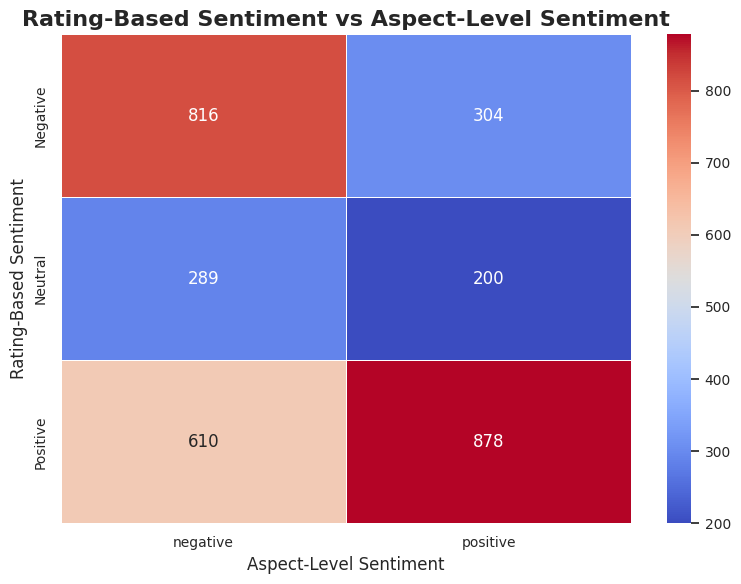

In [ ]:
# This heatmap compares review-level rating sentiment with
# aspect-level sentiment.
#
# Assignment usage:
# - Very strong visual to justify ABSA
# - Shows that a positive review can contain negative aspect opinions
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    rating_aspect_conflict_summary,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Rating-Based Sentiment vs Aspect-Level Sentiment")
plt.xlabel("Aspect-Level Sentiment")
plt.ylabel("Rating-Based Sentiment")

plt.tight_layout()
plt.savefig(
    "visualizations_notebook2/rating_sentiment_vs_aspect_sentiment_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Save Conflict Examples**

In [ ]:
# This cell saves examples where rating-based sentiment and
# aspect-level sentiment conflict.
#
# Assignment usage:
# - Useful for Discussion section
# - Demonstrates the value of ABSA
# ============================================================

rating_aspect_conflict_examples = rating_aspect_conflicts[
    [
        "app",
        "rating",
        "rating_sentiment",
        "sentence",
        "category",
        "term",
        "sentiment"
    ]
].head(30)

rating_aspect_conflict_examples.to_csv(
    "results_notebook2/rating_aspect_conflict_examples.csv",
    index=False
)

rating_aspect_conflict_examples

,app,rating,rating_sentiment,sentence,category,term,sentiment
0,whatsapp-messenger,4,Positive,I just drained about 15-20 percent of my phone...,efficiency,video call,negative
1,discord,4,Positive,"On an iPad Pro, I would honestly expect somewa...",effectiveness,share,negative
2,teamspeak-3,5,Positive,Would be awesome if you could press the volume...,usability,volume,negative
4,discord,5,Positive,But the mobile recent update just killed it.,general,recent update,negative
7,whatsapp-messenger,4,Positive,However... getting added to group chats is so ...,usability,group chat,negative
8,whatsapp-messenger,1,Negative,I love status updates too.,general,status update,positive
10,free-tone-calling-texting,4,Positive,Especially not without the consent of the send...,security,unknown_term,negative
18,discord,5,Positive,"In order to stop them, you have to mute everyt...",effectiveness,notification,negative
25,facebook,4,Positive,My mom’s FB says she has 2 unread messages whe...,effectiveness,unread message,negative
27,facebook,5,Positive,No matter how many times I click reload I’m un...,reliability,content,negative


# **Save Updated Dataset After Phase 5**

In [ ]:
# This file includes:
# - custom opinion word extraction
# - VADER results
# - explicit/implicit opinion labels
#
# It can be used in Notebook 3 if needed.
# ============================================================

aspect_df.to_csv(
    "results_notebook2/aspect_level_social_reviews_with_opinion_features.csv",
    index=False
)

print("Updated Notebook 2 dataset saved:")
print("results_notebook2/aspect_level_social_reviews_with_opinion_features.csv")

Updated Notebook 2 dataset saved:
results_notebook2/aspect_level_social_reviews_with_opinion_features.csv


# 8. Final ABSA Insight Summary and Export

This final phase summarizes the strongest opinion mining and ABSA findings from Notebook 2.

The goals are:

1. Generate final insight tables for the report.
2. Identify the strongest findings from aspect term analysis.
3. Summarize VADER limitations.
4. Summarize explicit and implicit opinion patterns.
5. Summarize rating-level vs aspect-level sentiment conflicts.
6. Export all Notebook 2 results and visualizations as a ZIP file.

The exported files will be used in:

- Final report
- PowerPoint presentation
- GitHub repository
- Appendix

# **Create Final ABSA Insight Table**

In [ ]:
# This cell creates a compact final insight table for the report.
#
# Assignment usage:
# - Supports Result & Visualization section
# - Supports Discussion section
# - Helps summarize Notebook 2 findings clearly
# ============================================================

final_absa_insights = pd.DataFrame([
    {
        "Insight Area": "Most Frequent Aspect Term",
        "Finding": term_sentiment_comparison.sort_values("total", ascending=False).index[0],
        "Evidence": f"{term_sentiment_comparison.sort_values('total', ascending=False)['total'].iloc[0]} total mentions"
    },
    {
        "Insight Area": "Most Negative Frequent Aspect Term",
        "Finding": term_sentiment_comparison.sort_values("negative_percentage", ascending=False).index[0],
        "Evidence": f"{term_sentiment_comparison.sort_values('negative_percentage', ascending=False)['negative_percentage'].iloc[0]}% negative"
    },
    {
        "Insight Area": "Highest-Risk Negative Term",
        "Finding": high_risk_negative_terms.index[0],
        "Evidence": f"{high_risk_negative_terms['negative_percentage'].iloc[0]}% negative sentiment"
    },
    {
        "Insight Area": "VADER Agreement",
        "Finding": "Low agreement with dataset aspect labels",
        "Evidence": f"{vader_agreement_rate:.2f}% agreement"
    },
    {
        "Insight Area": "Opinion Expression",
        "Finding": opinion_expression_summary.iloc[0]["Opinion Expression Type"],
        "Evidence": f"{opinion_expression_summary.iloc[0]['Percentage']}% of aspect sentences"
    },
    {
        "Insight Area": "Rating vs Aspect Conflict",
        "Finding": "Overall rating does not always match aspect sentiment",
        "Evidence": f"{len(rating_aspect_conflicts)} conflict rows found"
    }
])

final_absa_insights.to_csv(
    "results_notebook2/final_absa_insight_summary.csv",
    index=False
)

final_absa_insights

,Insight Area,Finding,Evidence
0,Most Frequent Aspect Term,notification,187 total mentions
1,Most Negative Frequent Aspect Term,account,70.75% negative
2,Highest-Risk Negative Term,loading screen,100.0% negative sentiment
3,VADER Agreement,Low agreement with dataset aspect labels,48.37% agreement
4,Opinion Expression,Implicit,59.06% of aspect sentences
5,Rating vs Aspect Conflict,Overall rating does not always match aspect se...,914 conflict rows found


# **Best Visuals Recommendation Table**

In [ ]:
# This cell lists the strongest Notebook 2 visuals for the final report.
#
# Assignment usage:
# - Helps decide which figures to include in the report and slides
# ============================================================

best_visuals = pd.DataFrame([
    {
        "Visual File": "top_aspect_terms_sentiment_comparison.png",
        "Use In Report Section": "ABSA / Result & Visualization",
        "Why It Is Important": "Shows positive vs negative sentiment for common aspect terms"
    },
    {
        "Visual File": "high_risk_negative_aspect_terms.png",
        "Use In Report Section": "Discussion / ABSA",
        "Why It Is Important": "Identifies app features with highest negative sentiment percentage"
    },
    {
        "Visual File": "app_high_risk_negative_terms_heatmap.png",
        "Use In Report Section": "Result & Visualization",
        "Why It Is Important": "Shows which apps are linked to high-risk negative aspect terms"
    },
    {
        "Visual File": "custom_positive_opinion_words.png",
        "Use In Report Section": "Opinion Mining",
        "Why It Is Important": "Shows how users express positive opinions"
    },
    {
        "Visual File": "custom_negative_opinion_words.png",
        "Use In Report Section": "Opinion Mining",
        "Why It Is Important": "Shows how users express negative opinions"
    },
    {
        "Visual File": "vader_vs_dataset_sentiment_heatmap.png",
        "Use In Report Section": "Discussion",
        "Why It Is Important": "Shows limitations of lexicon-based sentiment analysis"
    },
    {
        "Visual File": "explicit_vs_implicit_opinions.png",
        "Use In Report Section": "Opinion Mining",
        "Why It Is Important": "Shows how much sentiment is explicit vs contextual"
    },
    {
        "Visual File": "rating_sentiment_vs_aspect_sentiment_heatmap.png",
        "Use In Report Section": "ABSA / Discussion",
        "Why It Is Important": "Proves rating alone cannot explain aspect-level opinions"
    }
])

best_visuals.to_csv(
    "results_notebook2/best_visuals_for_report.csv",
    index=False
)

best_visuals

,Visual File,Use In Report Section,Why It Is Important
0,top_aspect_terms_sentiment_comparison.png,ABSA / Result & Visualization,Shows positive vs negative sentiment for commo...
1,high_risk_negative_aspect_terms.png,Discussion / ABSA,Identifies app features with highest negative ...
2,app_high_risk_negative_terms_heatmap.png,Result & Visualization,Shows which apps are linked to high-risk negat...
3,custom_positive_opinion_words.png,Opinion Mining,Shows how users express positive opinions
4,custom_negative_opinion_words.png,Opinion Mining,Shows how users express negative opinions
5,vader_vs_dataset_sentiment_heatmap.png,Discussion,Shows limitations of lexicon-based sentiment a...
6,explicit_vs_implicit_opinions.png,Opinion Mining,Shows how much sentiment is explicit vs contex...
7,rating_sentiment_vs_aspect_sentiment_heatmap.png,ABSA / Discussion,Proves rating alone cannot explain aspect-leve...


# **Create Notebook 2 Summary Text File**

In [ ]:
# This cell creates a written summary of Notebook 2.
#
# Assignment usage:
# - Can be used in README
# - Can be used in appendix
# - Helps write the report Discussion section
# ============================================================

notebook2_summary = f"""

Input Dataset:
aspect_level_social_reviews.csv

Dataset Shape:
{aspect_df.shape}

Main Dataset Characteristics:
- Unique apps: {aspect_df['app'].nunique()}
- Unique aspect categories: {aspect_df['category'].nunique()}
- Unique aspect terms: {aspect_df['term_clean'].nunique()}
- Aspect sentiment classes: {aspect_df['sentiment'].unique().tolist()}

Aspect Sentiment Distribution:
{aspect_df['sentiment'].value_counts().to_string()}

Top Aspect Terms:
{term_sentiment_comparison.sort_values('total', ascending=False).head(10).to_string()}

High-Risk Negative Aspect Terms:
{high_risk_negative_terms.head(10).to_string()}

Custom Positive Opinion Words:
{custom_positive_words_df.head(10).to_string(index=False)}

Custom Negative Opinion Words:
{custom_negative_words_df.head(10).to_string(index=False)}

VADER Agreement:
VADER agreed with dataset-provided aspect sentiment labels in {vader_agreement_rate:.2f}% of cases.

Explicit vs Implicit Opinion Summary:
{opinion_expression_summary.to_string(index=False)}

Rating-Based Sentiment vs Aspect Sentiment:
{rating_aspect_conflict_summary.to_string()}

Number of Rating-Aspect Conflict Rows:
{len(rating_aspect_conflicts)}

Key Findings:
1. Aspect terms such as notification, account, version, chat, and group were frequently discussed.
2. Some terms appeared in both positive and negative contexts, showing mixed user opinions.
3. High-risk negative terms included loading screen, last update, customer support, news feed, volume, and account.
4. Custom opinion word extraction separated actual sentiment expressions from aspect terms.
5. VADER achieved limited agreement with dataset aspect labels, showing that lexicon-based sentiment analysis may miss context.
6. Most opinion expressions were implicit rather than explicit, showing that social networking app reviews often require contextual understanding.
7. Rating-based sentiment and aspect-level sentiment did not always match, proving that ABSA provides deeper insight than ratings alone.

Notebook 2 Use:
- Opinion Mining section
- ABSA section
- Result & Visualization section
- Discussion section
- Appendix
"""

with open("results_notebook2/notebook2_summary.txt", "w", encoding="utf-8") as f:
    f.write(notebook2_summary)

print(notebook2_summary)
print("Notebook 2 summary saved as results_notebook2/notebook2_summary.txt")



Input Dataset:
aspect_level_social_reviews.csv

Dataset Shape:
(3097, 29)

Main Dataset Characteristics:
- Unique apps: 6
- Unique aspect categories: 9
- Unique aspect terms: 85
- Aspect sentiment classes: ['negative', 'positive']

Aspect Sentiment Distribution:
sentiment
negative    1715
positive    1382

Top Aspect Terms:
sentiment     positive  negative  total  negative_percentage
term_clean                                                  
notification        64       123    187                65.78
version             75       103    178                57.87
chat                91        62    153                40.52
account             43       104    147                70.75
group               78        67    145                46.21
photo               65        71    136                52.21
sound               50        61    111                54.95
money               45        66    111                59.46
setting             46        62    108                57.41
s

# **Save Final Updated Aspect Dataset**

In [ ]:
# This file contains the aspect-level dataset with:
# - cleaned aspect terms
# - custom opinion word extraction
# - VADER sentiment scores
# - explicit/implicit opinion labels
#
# This may be used in Notebook 3 if we want extra features.
# ============================================================

aspect_df.to_csv(
    "results_notebook2/final_aspect_level_social_reviews_with_opinion_features.csv",
    index=False
)

print("Final Notebook 2 dataset saved:")
print("results_notebook2/final_aspect_level_social_reviews_with_opinion_features.csv")

Final Notebook 2 dataset saved:
results_notebook2/final_aspect_level_social_reviews_with_opinion_features.csv


# **Check Final Output Files**

In [ ]:
# This cell lists all files created in Notebook 2.
# ============================================================

print("=" * 100)
print("NOTEBOOK 2 FINAL OUTPUT FILE CHECK")
print("=" * 100)

print("\nFiles in results_notebook2:")
for file in sorted(os.listdir("results_notebook2")):
    print("-", file)

print("\nFiles in visualizations_notebook2:")
for file in sorted(os.listdir("visualizations_notebook2")):
    print("-", file)

print("=" * 100)

NOTEBOOK 2 FINAL OUTPUT FILE CHECK

Files in results_notebook2:
- app_aspect_row_distribution.csv
- app_high_risk_negative_terms.csv
- aspect_category_distribution.csv
- aspect_level_social_reviews_with_opinion_features.csv
- aspect_level_social_reviews_with_vader.csv
- aspect_sentiment_distribution.csv
- aspect_term_frequency_preview.csv
- best_visuals_for_report.csv
- custom_negative_opinion_words.csv
- custom_opinion_word_coverage.csv
- custom_positive_opinion_words.csv
- examples_with_custom_opinion_words.csv
- examples_without_custom_opinion_words.csv
- explicit_implicit_by_category.csv
- explicit_implicit_by_sentiment.csv
- explicit_implicit_opinion_summary.csv
- explicit_opinion_examples.csv
- final_absa_insight_summary.csv
- final_aspect_level_social_reviews_with_opinion_features.csv
- high_risk_negative_aspect_terms.csv
- implicit_opinion_examples.csv
- notebook2_summary.txt
- opinion_word_coverage_by_sentiment.csv
- rating_aspect_conflict_examples.csv
- rating_sentiment_vs_as

# **ZIP Notebook 2 Outputs**

In [ ]:
# This cell compresses all Notebook 2 result tables and visualizations.
#
# Assignment usage:
# - Save for report writing
# - Save for PowerPoint preparation
# - Upload to GitHub repository
# ============================================================

zip_path = "exports_notebook2/CDS6344_Group9_Notebook2_Outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for folder in ["results_notebook2", "visualizations_notebook2"]:
        for root, dirs, files_in_folder in os.walk(folder):
            for file in files_in_folder:
                file_path = os.path.join(root, file)
                zipf.write(file_path)

print("Notebook 2 outputs zipped successfully:")
print(zip_path)

Notebook 2 outputs zipped successfully:
exports_notebook2/CDS6344_Group9_Notebook2_Outputs.zip


# **Download Notebook 2 ZIP**

In [ ]:
# Keep this ZIP safely because it will be used in the report,
# PowerPoint slides, GitHub repository, and Notebook 3 if needed.
# ============================================================

from google.colab import files

files.download("exports_notebook2/CDS6344_Group9_Notebook2_Outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Final Notebook 2 Completion Summary**

In [ ]:
# ============================================================
# NOTEBOOK 2 COMPLETION SUMMARY
# ============================================================

print("=" * 100)
print("NOTEBOOK 2 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("\nNotebook 2 produced:")
print("- Aspect term analysis outputs")
print("- High-risk negative aspect term outputs")
print("- Custom positive and negative opinion word outputs")
print("- VADER lexicon comparison outputs")
print("- Explicit vs implicit opinion outputs")
print("- Rating vs aspect sentiment conflict outputs")
print("- Final ABSA insight summary")
print("- Final Notebook 2 ZIP file")

print("\nMain files to use later:")
print("- results_notebook2/final_aspect_level_social_reviews_with_opinion_features.csv")
print("- results_notebook2/final_absa_insight_summary.csv")
print("- results_notebook2/best_visuals_for_report.csv")
print("- results_notebook2/notebook2_summary.txt")
print("- exports_notebook2/CDS6344_Group9_Notebook2_Outputs.zip")

print("\nNext notebook:")
print("CDS6344_Group9_Notebook3_Model_Training_Evaluation.ipynb")

print("=" * 100)

NOTEBOOK 2 COMPLETED SUCCESSFULLY

Notebook 2 produced:
- Aspect term analysis outputs
- High-risk negative aspect term outputs
- Custom positive and negative opinion word outputs
- VADER lexicon comparison outputs
- Explicit vs implicit opinion outputs
- Rating vs aspect sentiment conflict outputs
- Final ABSA insight summary
- Final Notebook 2 ZIP file

Main files to use later:
- results_notebook2/final_aspect_level_social_reviews_with_opinion_features.csv
- results_notebook2/final_absa_insight_summary.csv
- results_notebook2/best_visuals_for_report.csv
- results_notebook2/notebook2_summary.txt
- exports_notebook2/CDS6344_Group9_Notebook2_Outputs.zip

Next notebook:
CDS6344_Group9_Notebook3_Model_Training_Evaluation.ipynb


In [ ]:
# ============================================================
# NOTEBOOK 2 FINAL OUTPUT REPORT GENERATOR
# ============================================================
# This cell creates a clean final report of Notebook 2 outputs.
#
# Use:
# - Run this at the end of Notebook 2
# - Copy the printed output and send it for checking
# - It also saves the report as a .txt file
#
# Assignment usage:
# - Helps verify Opinion Mining and ABSA outputs
# - Useful for README, appendix, report writing, and team review
# ============================================================

from io import StringIO

notebook2_report = StringIO()

def write_line(text=""):
    print(text)
    notebook2_report.write(str(text) + "\n")


write_line("=" * 100)
write_line("CDS6344 GROUP 9 - NOTEBOOK 2 FINAL OUTPUT REPORT")
write_line("=" * 100)

# ------------------------------------------------------------
# 1. Dataset summary
# ------------------------------------------------------------
write_line("\n1. DATASET SUMMARY")
write_line("-" * 100)

write_line(f"Dataset shape: {aspect_df.shape}")
write_line(f"Unique reviews: {aspect_df['review_id'].nunique()}")
write_line(f"Unique sentences: {aspect_df['sentence_id'].nunique()}")
write_line(f"Unique apps: {aspect_df['app'].nunique()}")
write_line(f"Unique aspect categories: {aspect_df['category'].nunique()}")

if "term_clean" in aspect_df.columns:
    write_line(f"Unique cleaned aspect terms: {aspect_df['term_clean'].nunique()}")
else:
    write_line(f"Unique aspect terms: {aspect_df['term'].nunique()}")

# ------------------------------------------------------------
# 2. Aspect sentiment distribution
# ------------------------------------------------------------
write_line("\n2. ASPECT SENTIMENT DISTRIBUTION")
write_line("-" * 100)

if "sentiment" in aspect_df.columns:
    sentiment_counts = aspect_df["sentiment"].value_counts()
    sentiment_percentages = (aspect_df["sentiment"].value_counts(normalize=True) * 100).round(2)

    sentiment_summary_output = pd.DataFrame({
        "Count": sentiment_counts,
        "Percentage": sentiment_percentages
    })

    write_line(sentiment_summary_output.to_string())
else:
    write_line("sentiment column not found.")

# ------------------------------------------------------------
# 3. Aspect category distribution
# ------------------------------------------------------------
write_line("\n3. ASPECT CATEGORY DISTRIBUTION")
write_line("-" * 100)

if "category" in aspect_df.columns:
    category_counts = aspect_df["category"].value_counts()
    category_percentages = (aspect_df["category"].value_counts(normalize=True) * 100).round(2)

    category_summary_output = pd.DataFrame({
        "Count": category_counts,
        "Percentage": category_percentages
    })

    write_line(category_summary_output.to_string())
else:
    write_line("category column not found.")

# ------------------------------------------------------------
# 4. App distribution
# ------------------------------------------------------------
write_line("\n4. APP DISTRIBUTION")
write_line("-" * 100)

if "app" in aspect_df.columns:
    app_counts = aspect_df["app"].value_counts()
    app_percentages = (aspect_df["app"].value_counts(normalize=True) * 100).round(2)

    app_summary_output = pd.DataFrame({
        "Count": app_counts,
        "Percentage": app_percentages
    })

    write_line(app_summary_output.to_string())
else:
    write_line("app column not found.")

# ------------------------------------------------------------
# 5. Top positive aspect terms
# ------------------------------------------------------------
write_line("\n5. TOP POSITIVE ASPECT TERMS")
write_line("-" * 100)

if "top_positive_aspect_terms" in globals():
    write_line(top_positive_aspect_terms.head(15).to_string(index=False))
else:
    write_line("top_positive_aspect_terms not found. Run Phase 2 first.")

# ------------------------------------------------------------
# 6. Top negative aspect terms
# ------------------------------------------------------------
write_line("\n6. TOP NEGATIVE ASPECT TERMS")
write_line("-" * 100)

if "top_negative_aspect_terms" in globals():
    write_line(top_negative_aspect_terms.head(15).to_string(index=False))
else:
    write_line("top_negative_aspect_terms not found. Run Phase 2 first.")

# ------------------------------------------------------------
# 7. Top aspect terms sentiment comparison
# ------------------------------------------------------------
write_line("\n7. TOP ASPECT TERMS SENTIMENT COMPARISON")
write_line("-" * 100)

if "term_sentiment_comparison" in globals():
    write_line(
        term_sentiment_comparison
        .sort_values("total", ascending=False)
        .head(15)
        .to_string()
    )
else:
    write_line("term_sentiment_comparison not found. Run Phase 2 first.")

# ------------------------------------------------------------
# 8. High-risk negative aspect terms
# ------------------------------------------------------------
write_line("\n8. HIGH-RISK NEGATIVE ASPECT TERMS")
write_line("-" * 100)

if "high_risk_negative_terms" in globals():
    write_line(high_risk_negative_terms.head(15).to_string())
else:
    write_line("high_risk_negative_terms not found. Run Phase 2 first.")

# ------------------------------------------------------------
# 9. App-level high-risk aspect term summary
# ------------------------------------------------------------
write_line("\n9. APP-LEVEL HIGH-RISK NEGATIVE ASPECT TERM SUMMARY")
write_line("-" * 100)

if "app_high_risk_summary" in globals():
    write_line(app_high_risk_summary.to_string())
else:
    write_line("app_high_risk_summary not found. Run Phase 2 first.")

# ------------------------------------------------------------
# 10. Custom positive opinion words
# ------------------------------------------------------------
write_line("\n10. CUSTOM POSITIVE OPINION WORDS")
write_line("-" * 100)

if "custom_positive_words_df" in globals():
    write_line(custom_positive_words_df.head(20).to_string(index=False))
else:
    write_line("custom_positive_words_df not found. Run Phase 3 first.")

# ------------------------------------------------------------
# 11. Custom negative opinion words
# ------------------------------------------------------------
write_line("\n11. CUSTOM NEGATIVE OPINION WORDS")
write_line("-" * 100)

if "custom_negative_words_df" in globals():
    write_line(custom_negative_words_df.head(20).to_string(index=False))
else:
    write_line("custom_negative_words_df not found. Run Phase 3 first.")

# ------------------------------------------------------------
# 12. Custom opinion word coverage
# ------------------------------------------------------------
write_line("\n12. CUSTOM OPINION WORD COVERAGE")
write_line("-" * 100)

if "custom_opinion_coverage" in globals():
    write_line(custom_opinion_coverage.to_string(index=False))
else:
    write_line("custom_opinion_coverage not found. Run Phase 3 first.")

# ------------------------------------------------------------
# 13. Opinion word coverage by sentiment
# ------------------------------------------------------------
write_line("\n13. OPINION WORD COVERAGE BY SENTIMENT")
write_line("-" * 100)

if "opinion_word_by_sentiment" in globals():
    write_line(opinion_word_by_sentiment.to_string())
else:
    write_line("opinion_word_by_sentiment not found. Run Phase 3 first.")

# ------------------------------------------------------------
# 14. VADER sentiment distribution
# ------------------------------------------------------------
write_line("\n14. VADER SENTIMENT DISTRIBUTION")
write_line("-" * 100)

if "vader_sentiment_summary" in globals():
    write_line(vader_sentiment_summary.to_string(index=False))
else:
    write_line("vader_sentiment_summary not found. Run Phase 4 first.")

# ------------------------------------------------------------
# 15. Dataset sentiment vs VADER sentiment
# ------------------------------------------------------------
write_line("\n15. DATASET ASPECT SENTIMENT VS VADER SENTIMENT")
write_line("-" * 100)

if "vader_comparison" in globals():
    write_line(vader_comparison.to_string())
else:
    write_line("vader_comparison not found. Run Phase 4 first.")

# ------------------------------------------------------------
# 16. VADER agreement rate
# ------------------------------------------------------------
write_line("\n16. VADER AGREEMENT RATE")
write_line("-" * 100)

if "vader_agreement_rate" in globals():
    write_line(f"VADER agreement rate: {vader_agreement_rate:.2f}%")
else:
    write_line("vader_agreement_rate not found. Run Phase 4 first.")

# ------------------------------------------------------------
# 17. VADER agreement by category
# ------------------------------------------------------------
write_line("\n17. VADER AGREEMENT BY ASPECT CATEGORY")
write_line("-" * 100)

if "vader_agreement_by_category" in globals():
    write_line(vader_agreement_by_category.to_string(index=False))
else:
    write_line("vader_agreement_by_category not found. Run Phase 4 first.")

# ------------------------------------------------------------
# 18. Explicit vs implicit opinion summary
# ------------------------------------------------------------
write_line("\n18. EXPLICIT VS IMPLICIT OPINION SUMMARY")
write_line("-" * 100)

if "opinion_expression_summary" in globals():
    write_line(opinion_expression_summary.to_string(index=False))
else:
    write_line("opinion_expression_summary not found. Run Phase 5 first.")

# ------------------------------------------------------------
# 19. Explicit vs implicit by sentiment
# ------------------------------------------------------------
write_line("\n19. EXPLICIT VS IMPLICIT BY ASPECT SENTIMENT")
write_line("-" * 100)

if "explicit_implicit_by_sentiment" in globals():
    write_line(explicit_implicit_by_sentiment.to_string())
else:
    write_line("explicit_implicit_by_sentiment not found. Run Phase 5 first.")

# ------------------------------------------------------------
# 20. Explicit vs implicit by category
# ------------------------------------------------------------
write_line("\n20. EXPLICIT VS IMPLICIT BY ASPECT CATEGORY")
write_line("-" * 100)

if "explicit_implicit_by_category" in globals():
    write_line(explicit_implicit_by_category.to_string())
else:
    write_line("explicit_implicit_by_category not found. Run Phase 5 first.")

# ------------------------------------------------------------
# 21. Rating sentiment vs aspect sentiment
# ------------------------------------------------------------
write_line("\n21. RATING-BASED SENTIMENT VS ASPECT-LEVEL SENTIMENT")
write_line("-" * 100)

if "rating_aspect_conflict_summary" in globals():
    write_line(rating_aspect_conflict_summary.to_string())
else:
    write_line("rating_aspect_conflict_summary not found. Run Phase 5 first.")

# ------------------------------------------------------------
# 22. Rating-aspect conflict count
# ------------------------------------------------------------
write_line("\n22. RATING-ASPECT CONFLICT COUNT")
write_line("-" * 100)

if "rating_aspect_conflicts" in globals():
    write_line(f"Number of rating-aspect conflict rows: {len(rating_aspect_conflicts)}")
else:
    write_line("rating_aspect_conflicts not found. Run Phase 5 first.")

# ------------------------------------------------------------
# 23. Final ABSA insight summary
# ------------------------------------------------------------
write_line("\n23. FINAL ABSA INSIGHT SUMMARY")
write_line("-" * 100)

if "final_absa_insights" in globals():
    write_line(final_absa_insights.to_string(index=False))
else:
    write_line("final_absa_insights not found. Run Phase 6 first.")

# ------------------------------------------------------------
# 24. Best visuals for report
# ------------------------------------------------------------
write_line("\n24. BEST VISUALS FOR REPORT")
write_line("-" * 100)

if "best_visuals" in globals():
    write_line(best_visuals.to_string(index=False))
else:
    write_line("best_visuals not found. Run Phase 6 first.")

# ------------------------------------------------------------
# 25. Files created
# ------------------------------------------------------------
write_line("\n25. FILES CREATED IN results_notebook2")
write_line("-" * 100)

if os.path.exists("results_notebook2"):
    for file in sorted(os.listdir("results_notebook2")):
        write_line(f"- {file}")
else:
    write_line("results_notebook2 folder not found.")

write_line("\n26. FILES CREATED IN visualizations_notebook2")
write_line("-" * 100)

if os.path.exists("visualizations_notebook2"):
    for file in sorted(os.listdir("visualizations_notebook2")):
        write_line(f"- {file}")
else:
    write_line("visualizations_notebook2 folder not found.")

write_line("\n" + "=" * 100)
write_line("END OF NOTEBOOK 2 FINAL OUTPUT REPORT")
write_line("=" * 100)

# Save report
notebook2_report_text = notebook2_report.getvalue()

with open("results_notebook2/notebook2_final_output_report.txt", "w", encoding="utf-8") as f:
    f.write(notebook2_report_text)

print("\nNotebook 2 final output report saved as:")
print("results_notebook2/notebook2_final_output_report.txt")

CDS6344 GROUP 9 - NOTEBOOK 2 FINAL OUTPUT REPORT

1. DATASET SUMMARY
----------------------------------------------------------------------------------------------------
Dataset shape: (3097, 29)
Unique reviews: 1615
Unique sentences: 2965
Unique apps: 6
Unique aspect categories: 9
Unique cleaned aspect terms: 85

2. ASPECT SENTIMENT DISTRIBUTION
----------------------------------------------------------------------------------------------------
           Count  Percentage
sentiment                   
negative    1715       55.38
positive    1382       44.62

3. ASPECT CATEGORY DISTRIBUTION
----------------------------------------------------------------------------------------------------
               Count  Percentage
category                        
usability        842       27.19
general          756       24.41
effectiveness    379       12.24
efficiency       337       10.88
security         284        9.17
cost             194        6.26
reliability      178        5.75
enj